# Interpretable Traffic Sign Recognition — Intelligent Systems Project
**Authors:** Dario Bandecchi, Gabriele Caioli  
**A.Y.:** 2025/2026

## Pipeline overview
```
Street image
    │
    ▼
YOLO (fine-tuned)  ──►  Bounding boxes + class + confidence
    │
    ▼ (crop each detected sign)
ProtoTree          ──►  Interpretable classification (prototype-based decision tree)
    │
    ▼
Final output: annotated image with class and confidence
```

## Training strategy
```
Phase 1 — Variant comparison   5 variants × fold 0 × default config  =   5 runs
                                         ↓ pick best variant
Phase 2 — Hyperparameter grid  1 variant × fold 0 × 4 configs        =   4 runs
                                         ↓ pick best config
Phase 3 — Cross-validation     1 variant  × all 5 folds              =   5 runs
                                         ↓ final reliable estimate
```

## Notebook sections
1. [Setup & Imports](#1-setup)
2. [Paths & Configuration](#2-paths)
3. [COCO to YOLO Conversion](#3-coco-to-yolo)
4. [Dataset Exploration](#4-exploration)
5. [K-Fold Split Generation](#5-splits)
6. [Phase 1 — YOLO Variant Comparison](#6-phase1)
7. [Phase 2 — Hyperparameter Grid Search](#7-phase2)
8. [Phase 3 — Cross-Validation on Best Config](#8-phase3)
9. [YOLO Final Evaluation](#9-yolo-eval)
10. [Crop Extraction (YOLO → ProtoTree input)](#10-crops)
11. [ProtoTree Training & Visualization](#11-prototree)
12. [ProtoTree Evaluation](#12-prototree-eval)
13. [End-to-End Pipeline](#13-pipeline)
14. [Video Demo with YOLO](#14-video-demo)

---
## 1. Setup & Imports <a id='1-setup'></a>

In [7]:
# ── Hardware ──────────────────────────────────────────────────────────────────
USE_GPU = True   # Set to True to use GPU if available

# ── Reproducibility ───────────────────────────────────────────────────────────
SEED = 42

In [8]:
# ── Install dependencies (run once) ──────────────────────────────────────────
%pip install ultralytics
%pip install torch torchvision
%pip install opencv-python-headless matplotlib seaborn scikit-learn pandas
%pip install iterative-stratification
%pip install tqdm Pillow

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [9]:
# ── Imports ──────────────────────────────────────────────────────────
import os
import sys
import json
import time
import glob
import random
import subprocess
from pathlib import Path
from collections import defaultdict, Counter

import yaml
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import seaborn as sns
import cv2
from PIL import Image
from tqdm import tqdm

import torch
from torch.utils.data import DataLoader
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder

from ultralytics import YOLO

from sklearn.metrics import confusion_matrix, classification_report
from iterstrat.ml_stratifiers import MultilabelStratifiedShuffleSplit, MultilabelStratifiedKFold

# Add ProtoTree to Python's search path to enable imports
sys.path.insert(0, str(Path("ProtoTree")))   
from prototree.prototree import ProtoTree

In [10]:
# Setup device
DEVICE = torch.device("cuda" if (USE_GPU and torch.cuda.is_available()) else "cpu")
print(f"Using device: {DEVICE}")
if (USE_GPU and torch.cuda.is_available()):
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Using device: cuda
GPU: NVIDIA A100-SXM4-80GB


In [11]:
# Set seed for reproducibility
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if (USE_GPU and torch.cuda.is_available()):
    torch.cuda.manual_seed_all(SEED)

---
## 2. Paths & Configuration <a id='2-paths'></a>

**Expected directory structure:**
```
IntelligentSystemProject/
├── dataset/                            # All original images and COCO/YOLO labels
│   ├── images/                         # Original images (.jpg / .png)
│   └── labels/                         # YOLO txt annotations & COCO labels.json
├── checkpoints/                        # Auto-generated YOLO & ProtoTree weights
├── crops_split/                        # Extracted class patches for ProtoTree training
├── results/                            # Validation metrics, logs, and plots
├── splits/                             # Auto-generated K-fold split text configs
├── src/
│   ├── ProtoTree/                      # Pre-included and customized ProtoTree library (to use our custom training data)
│   └── traffic_signs_IS_project.ipynb  # This file
└── README.md                           # README
```

In [12]:
# ── Paths Setup ───────────────────────────────────
PROJECT_ROOT = Path("../")
DATASET_DIR  = PROJECT_ROOT / "dataset"

IMAGES_DIR      = DATASET_DIR  / "images"
LABELS_DIR      = DATASET_DIR  / "labels"
SPLITS_DIR      = PROJECT_ROOT / "splits"
CHECKPOINTS_DIR = PROJECT_ROOT / "checkpoints"
CROPS_SPLIT_DIR = PROJECT_ROOT / "crops_split"
RESULTS_DIR     = PROJECT_ROOT / "results"

for d in [SPLITS_DIR, CHECKPOINTS_DIR, CROPS_SPLIT_DIR, RESULTS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print("\nPaths configured:")
for name, path in [("Images",      IMAGES_DIR),
                   ("Labels",      LABELS_DIR),
                   ("Splits",      SPLITS_DIR),
                   ("Checkpoints", CHECKPOINTS_DIR),
                   ("Crops",       CROPS_SPLIT_DIR),
                   ("Results",     RESULTS_DIR)]:
    print(f"  {name:15s}: {path}  ({'✓ exists' if path.exists() else '✗ missing'})")


Paths configured:
  Images         : ../dataset/images  (✓ exists)
  Labels         : ../dataset/labels  (✓ exists)
  Splits         : ../splits  (✓ exists)
  Checkpoints    : ../checkpoints  (✓ exists)
  Crops          : ../crops_split  (✓ exists)
  Results        : ../results  (✓ exists)


---
## 3. COCO to YOLO Conversion <a id='3-coco-to-yolo'></a>
This section converts the provided COCO `labels.json` into YOLO format `.txt` files.
Each image will have a corresponding `.txt` file in the `labels` directory.
Initially `labels.json` must be inside the `labels` directory.

In [ ]:
# ── Convert COCO to YOLO format ──────────────────────────────────────────────

coco_json_path = LABELS_DIR / "labels.json"

if coco_json_path.exists():
    print(f"Converting COCO annotations from {coco_json_path} to YOLO format...")
    with open(coco_json_path, 'r') as f:
        coco_data = json.load(f)
        
    # Create mapping from image_id to image info
    images_info = {img['id']: img for img in coco_data['images']}
    
    # Group annotations by image_id
    annotations_by_img = defaultdict(list)
    for ann in coco_data['annotations']:
        annotations_by_img[ann['image_id']].append(ann)
        
    # Convert and save
    converted_count = 0
    for img_id, img_info in tqdm(images_info.items(), desc="Converting to YOLO"):
        img_width = img_info['width']
        img_height = img_info['height']
        file_name = img_info['file_name']
        
        # Output label file name (change extension to .txt)
        txt_name = os.path.splitext(file_name)[0] + ".txt"
        txt_path = LABELS_DIR / txt_name
        
        anns = annotations_by_img.get(img_id, [])
        
        with open(txt_path, 'w') as f_out:
            for ann in anns:
                cat_id = ann['category_id']
                bbox = ann['bbox'] # [x_min, y_min, width, height]
                
                # Convert COCO to YOLO
                x_center = (bbox[0] + bbox[2] / 2.0) / img_width
                y_center = (bbox[1] + bbox[3] / 2.0) / img_height
                w = bbox[2] / img_width
                h = bbox[3] / img_height
                
                # Clip values to [0, 1] to be safe
                x_center = max(0.0, min(1.0, x_center))
                y_center = max(0.0, min(1.0, y_center))
                w = max(0.0, min(1.0, w))
                h = max(0.0, min(1.0, h))
                
                f_out.write(f"{cat_id} {x_center:.6f} {y_center:.6f} {w:.6f} {h:.6f}\n")
        
        converted_count += 1
        
    print(f"Successfully converted annotations for {converted_count} images.")
    
else:
    print(f"COCO JSON not found at {coco_json_path}. Skipping conversion.")


Converting COCO annotations from ../dataset/labels/labels.json to YOLO format...


Converting to YOLO: 100%|██████████| 14029/14029 [00:01<00:00, 8780.67it/s] 

Successfully converted annotations for 14029 images.


In [13]:
# ── Class definitions ─────────────────────────────────────────────────────────

# Mapping DFG Code -> Official Italian Name
CODE_TO_NAME = {
    "I-1": "Curva a sinistra",
    "I-1.1": "Curva a destra",
    "I-10": "Dosso / gobba sulla strada",
    "I-11": "Strada sdrucciolevole",
    "I-13": "Caduta massi (da destra)",
    "I-13.1": "Caduta massi (da sinistra)",
    "I-14": "Attraversamento pedonale",
    "I-15": "Bambini",
    "I-16": "Ciclisti",
    "I-17": "Animali domestici in strada",
    "I-18": "Fauna selvatica in strada",
    "I-19": "Lavori in corso",
    "I-2": "Doppia curva (prima a sinistra)",
    "I-2.1": "Doppia curva (prima a destra)",
    "I-20": "Semaforo",
    "I-25": "Pericolo generico",
    "I-27": "Incrocio con strada secondaria",
    "I-28": "Strada secondaria a sinistra",
    "I-28.1": "Strada secondaria a destra",
    "I-29": "Immissione da sinistra (angolo acuto)",
    "I-29.1": "Immissione da destra (angolo acuto)",
    "I-3": "Discesa pericolosa",
    "I-30": "Rotatoria",
    "I-32": "Ghiaccio sulla strada",
    "I-34": "Banchina pericolosa",
    "I-36": "Passaggio a livello con barriere",
    "I-37": "Passaggio a livello senza barriere",
    "I-38": "Croce di Sant'Andrea (binario singolo)",
    "I-39-1": "Preavviso passaggio a livello con barriere (3 barre)",
    "I-39-2": "Preavviso passaggio a livello con barriere (2 barre)",
    "I-39-3": "Preavviso passaggio a livello con barriere (1 barra)",
    "I-4": "Salita pericolosa",
    "I-5": "Restringimento carreggiata",
    "I-5.1": "Restringimento a destra",
    "I-5.2": "Restringimento a sinistra",
    "I-8": "Strada dissestata",
    "I-9": "Avvallamento",
    "II-1": "Dare la precedenza",
    "II-10.1": "Divieto di transito per veicoli con rimorchio",
    "II-14": "Divieto di transito per biciclette",
    "II-17": "Divieto di transito per pedoni",
    "II-18": "Divieto di transito per tutti i veicoli a motore",
    "II-19-4": "Divieto di transito (variante combinata)",
    "II-2": "Stop",
    "II-21": "Altezza massima",
    "II-22": "Massa massima",
    "II-23": "Carico massimo per asse",
    "II-26": "Divieto di svolta a sinistra",
    "II-26.1": "Divieto di svolta a destra",
    "II-28": "Divieto di sorpasso",
    "II-3": "Divieto di transito in entrambe le direzioni",
    "II-30-10": "Limite di velocita 10 km/h",
    "II-30-30": "Limite di velocita 30 km/h",
    "II-30-40": "Limite di velocita 40 km/h",
    "II-30-50": "Limite di velocita 50 km/h",
    "II-30-60": "Limite di velocita 60 km/h",
    "II-30-70": "Limite di velocita 70 km/h",
    "II-32": "Fermata obbligatoria: Dogana",
    "II-33": "Dare la precedenza ai veicoli in senso inverso",
    "II-34": "Divieto di sosta e di fermata",
    "II-35": "Divieto di sosta",
    "II-39": "Catene da neve obbligatorie",
    "II-4": "Divieto di accesso",
    "II-40": "Pista ciclabile obbligatoria",
    "II-41": "Percorso pedonale obbligatorio",
    "II-42": "Pista ciclabile e pedonale separata",
    "II-42.1": "Pista ciclabile e pedonale separata (variante)",
    "II-43": "Percorso misto pedoni e biciclette",
    "II-45": "Senso obbligatorio (dritto)",
    "II-45.1": "Senso obbligatorio (sinistra)",
    "II-45.2": "Senso obbligatorio (destra)",
    "II-46": "Direzioni consentite (dritto o sinistra)",
    "II-46.1": "Direzioni consentite (dritto o destra)",
    "II-46.2": "Direzioni consentite (sinistra o destra)",
    "II-47": "Transito obbligatorio a destra",
    "II-47.1": "Transito obbligatorio a sinistra",
    "II-48": "Rotatoria obbligatoria",
    "II-6": "Divieto di transito per autobus",
    "II-7": "Divieto di transito per autocarri",
    "II-7.1": "Divieto di transito per autocarri (massa specifica)",
    "II-8": "Divieto transito per veicoli cisterna (inquinanti acqua)",
    "III-1": "Precedenza rispetto al traffico inverso",
    "III-10": "Inizio autostrada",
    "III-105": "Progressiva chilometrica (strada statale)",
    "III-105.1": "Progressiva chilometrica (braccio)",
    "III-105.3": "Progressiva chilometrica (confine comunale)",
    "III-107-1": "Delimitatori modulari di curva (sinistra)",
    "III-107-2": "Delimitatori modulari di curva (destra)",
    "III-107.1-1": "Delimitatori modulari provvisori di curva (sinistra)",
    "III-107.1-2": "Delimitatori modulari provvisori di curva (destra)",
    "III-107.2-1": "Delimitatori di curva (sinistra)",
    "III-107.2-2": "Delimitatori di curva (destra)",
    "III-112": "Riduzione provvisoria delle corsie",
    "III-113": "Percorso obbligatorio provvisorio",
    "III-12": "Inizio strada riservata ai veicoli a motore",
    "III-120": "Uscita bambini da scuola",
    "III-120-1": "Uscita bambini da scuola (variante)",
    "III-120.1": "Fine zona scolastica",
    "III-123": "Controllo della velocita (autovelox)",
    "III-124": "Passaggio mezzi di soccorso",
    "III-14": "Inizio del comune / Inizio localita",
    "III-14.1": "Inizio localita (senza vigenza norme urbane)",
    "III-15": "Fine del comune / Fine localita",
    "III-16": "Fine divieto di sorpasso",
    "III-18-40": "Fine limite di velocita 40 km/h",
    "III-18-50": "Fine limite di velocita 50 km/h",
    "III-18-60": "Fine limite di velocita 60 km/h",
    "III-18-70": "Fine limite di velocita 70 km/h",
    "III-2": "Senso unico",
    "III-202-5": "Presegnalazione di direzione (extraurbana)",
    "III-203-2": "Cartello indicatore di direzione (variante)",
    "III-206-1": "Cartello indicatore (autostrada / via principale)",
    "III-21": "Fine di tutti i divieti",
    "III-23": "Fine pista ciclabile",
    "III-25": "Fine percorso ciclabile adiacente al marciapiede",
    "III-25.1": "Fine percorso misto pedonale e ciclabile",
    "III-27": "Zona a divieto di sosta",
    "III-29-30": "Zona a velocita limitata 30 km/h",
    "III-29-40": "Zona a velocita limitata 40 km/h",
    "III-3": "Strada con diritto di precedenza",
    "III-30-30": "Fine zona a velocita limitata 30 km/h",
    "III-33": "Strada residenziale / Zona di moderazione del traffico",
    "III-34": "Fine della zona residenziale",
    "III-35": "Parcheggio",
    "III-37": "Parcheggio con disco orario",
    "III-39": "Pronto soccorso",
    "III-40": "Assistenza meccanica",
    "III-42": "Scarico liquami / Stazione per veicoli a stazionamento",
    "III-43": "Rifornimento (stazione di servizio)",
    "III-45": "Ristorante",
    "III-46": "Bar",
    "III-47": "Area picnic",
    "III-5": "Attraversamento ciclabile",
    "III-50": "Campeggio o area sosta camper",
    "III-54": "Fermata di autobus",
    "III-59": "Centro informazioni",
    "III-6": "Attraversamento pedonale (indicazione)",
    "III-64": "Numero serpentina / progressiva",
    "III-68": "Nome del corso d'acqua",
    "III-74": "Radio informazioni stradali",
    "III-77": "Area di protezione idrica",
    "III-78": "Percorso ciclabile numerato",
    "III-8-1": "Strada senza uscita (variante)",
    "III-84": "Presegnalazione direzioni (extraurbana)",
    "III-84-1": "Presegnalazione direzioni (variante)",
    "III-85-2": "Utilizzo delle corsie in un incrocio (variante 2)",
    "III-85-3": "Utilizzo delle corsie in un incrocio (variante 3)",
    "III-85.1": "Utilizzo delle corsie con nomi di luoghi",
    "III-86-1": "Cartello indicatore: autostrada (sinistra)",
    "III-86-2": "Cartello indicatore: autostrada (destra)",
    "III-87": "Presegnalazione su strada extraurbana principale",
    "III-90": "Cartello sopra carreggiata: autostrada",
    "III-90.1": "Cartello sopra carreggiata: autostrada (variante)",
    "III-90.2": "Cartello sopra carreggiata: strada principale",
    "III-91": "Cartello per corsia sopra carreggiata",
    "IV-1": "Pannello di distanza",
    "IV-1.1": "Pannello di distanza (Stop ahead)",
    "IV-10": "Parcheggio per disabili",
    "IV-11": "Zona di rimozione forzata",
    "IV-12": "Validita del segnale in caso di pioggia",
    "IV-12.1": "Validita del segnale in caso di neve",
    "IV-13-1": "Pannello integrativo: distanza/orario (variante 1)",
    "IV-13-2": "Pannello integrativo: distanza/orario (variante 2)",
    "IV-13-3": "Pannello integrativo: distanza/orario (variante 3)",
    "IV-13-4": "Pannello integrativo: distanza/orario (variante 4)",
    "IV-13-5": "Pannello integrativo: distanza/orario (variante 5)",
    "IV-13-6": "Pannello integrativo: distanza/orario (variante 6)",
    "IV-13.1-2": "Pannello integrativo: orario giorni feriali (variante 2)",
    "IV-13.1-3": "Pannello integrativo: orario giorni feriali (variante 3)",
    "IV-13.1-4": "Pannello integrativo: orario giorni feriali (variante 4)",
    "IV-16": "Segnale valido per solchi / carreggiate",
    "IV-17": "Pista ciclabile bidirezionale",
    "IV-18": "Bambini in strada",
    "IV-2": "Pannello di estensione",
    "IV-20-1": "Pannello integrativo: categoria veicoli (variante 1)",
    "IV-3-1": "Pannello integrativo: orario (variante 1)",
    "IV-3-2": "Pannello integrativo: orario (variante 2)",
    "IV-3-4": "Pannello integrativo: orario (variante 4)",
    "IV-3-5": "Pannello integrativo: orario (variante 5)",
    "IV-5": "Pannello integrativo: freccia direzionale",
    "IV-6": "Pneumatici invernali o catene da neve",
    "VI-2.1": "Segnale di deviazione provvisoria (variante)",
    "VI-3-1": "Segnale di chiusura / ostacolo (sinistra)",
    "VI-3-2": "Segnale di chiusura / ostacolo (destra)",
    "VI-3.1-1": "Segnale di chiusura con freccia (sinistra)",
    "VI-3.1-2": "Segnale di chiusura con freccia (destra)",
    "VI-8": "Segnale per ostacoli / lavori (generico)",
    "VII-4": "Segnale turistico: indicazione generica",
    "VII-4-1": "Segnale turistico: variante 1",
    "VII-4-2": "Segnale turistico: variante 2",
    "VII-4.1-1": "Segnale informativo turistico: variante 1",
    "VII-4.3": "Segnale di area turistica",
    "VII-4.3-1": "Segnale di area turistica: variante 1",
    "VII-4.3-2": "Segnale di area turistica: variante 2",
    "VII-4.4-1": "Segnale di benvenuto: variante 1",
    "VII-4.4-2": "Segnale di benvenuto: variante 2",
    "X-1.1": "Segnale a messaggio variabile: variante 1",
    "X-1.2": "Segnale a messaggio variabile: variante 2",
    "X-4": "Pannello a messaggio variabile: informazioni traffico",
    "X-6-3": "Segnale luminoso di indicazione: variante 3"
}

coco_json_path = LABELS_DIR / "labels.json"
with open(coco_json_path, 'r') as f:
    coco_data = json.load(f)

CLASS_NAMES = {}
MACRO_CLASSES = {
    "warning": [],
    "prohibitory": [],
    "information": [],
    "additional": [],
    "special": [],
    "tourist": [],
    "variable": []
}

for cat in coco_data['categories']:
    cid = cat['id']
    code = cat['name']
    name = CODE_TO_NAME.get(code, code)
    CLASS_NAMES[cid] = name
    
    if code.startswith('I-'):
        MACRO_CLASSES['warning'].append(cid)
    elif code.startswith('II-'):
        MACRO_CLASSES['prohibitory'].append(cid)
    elif code.startswith('III-'):
        MACRO_CLASSES['information'].append(cid)
    elif code.startswith('IV-'):
        MACRO_CLASSES['additional'].append(cid)
    elif code.startswith('VI-'):
        MACRO_CLASSES['special'].append(cid)
    elif code.startswith('VII-'):
        MACRO_CLASSES['tourist'].append(cid)
    elif code.startswith('X-'):
        MACRO_CLASSES['variable'].append(cid)

NUM_CLASSES = len(CLASS_NAMES)

MACRO_COLORS = {
    "warning": (255, 165,   0),      # orange
    "prohibitory": (220,   0,   0),  # red
    "information": (  0,   0, 255),  # blue
    "additional": ( 128, 128, 128),  # gray
    "special": (142,  68, 173),      # purple
    "tourist": (139,  69,  19),      # brown
    "variable": (241, 196,  15),     # yellow
}

CLASS_TO_MACRO = {}
for macro, ids in MACRO_CLASSES.items():
    for cid in ids:
        CLASS_TO_MACRO[cid] = macro

print(f"Total classes : {NUM_CLASSES}")
print(f"Macro sizes   : { {k: len(v) for k, v in MACRO_CLASSES.items()} }")


Total classes : 200
Macro sizes   : {'warning': 37, 'prohibitory': 44, 'information': 74, 'additional': 26, 'special': 6, 'tourist': 9, 'variable': 4}


In [14]:
# ── Selected classes for ProtoTree (only 25 classes out of 200 for better interpretability) ──────────────────────────────────────
SELECTED_CLASSES = [
     0,  1,  2,  6, 14,
    16, 17, 18, 22, 32,
    37, 43, 49, 51, 52,
    53, 54, 55, 56, 59,
    60, 62, 68, 69, 70,
]

# Print the names of the selected classes
print("Selected classes for ProtoTree:")
for cid in SELECTED_CLASSES:
    print(f"Class {cid:2d}: {CLASS_NAMES.get(cid, f'class {cid}')}")

Selected classes for ProtoTree:
Class  0: Curva a sinistra
Class  1: Curva a destra
Class  2: Dosso / gobba sulla strada
Class  6: Attraversamento pedonale
Class 14: Semaforo
Class 16: Incrocio con strada secondaria
Class 17: Strada secondaria a sinistra
Class 18: Strada secondaria a destra
Class 22: Rotatoria
Class 32: Restringimento carreggiata
Class 37: Dare la precedenza
Class 43: Stop
Class 49: Divieto di sorpasso
Class 51: Limite di velocita 10 km/h
Class 52: Limite di velocita 30 km/h
Class 53: Limite di velocita 40 km/h
Class 54: Limite di velocita 50 km/h
Class 55: Limite di velocita 60 km/h
Class 56: Limite di velocita 70 km/h
Class 59: Divieto di sosta e di fermata
Class 60: Divieto di sosta
Class 62: Divieto di accesso
Class 68: Senso obbligatorio (dritto)
Class 69: Senso obbligatorio (sinistra)
Class 70: Senso obbligatorio (destra)


---
## 4. Dataset Exploration <a id='4-exploration'></a>

In [15]:
# ── Collect all image/label pairs ────────────────────────────────────────────
image_extensions = {".jpg", ".jpeg", ".png"}
image_paths = sorted([p for p in IMAGES_DIR.rglob("*")
                      if p.suffix.lower() in image_extensions])
print(f"Total images found: {len(image_paths)}")

records      = []
class_counts = np.zeros(NUM_CLASSES, dtype=int)

for img_path in tqdm(image_paths, desc="Parsing labels"):
    rel_path = img_path.relative_to(IMAGES_DIR)
    label_path = LABELS_DIR / rel_path.with_suffix(".txt")
    class_ids  = []
    if label_path.exists():
        with open(label_path) as f:
            for line in f:
                parts = line.strip().split()
                if parts:
                    cid = int(float(parts[0]))
                    if cid >= NUM_CLASSES or cid < 0:
                        print(f"\nWarning: ignoring class {cid} in file {label_path.name}")
                        continue
                    class_ids.append(cid)
                    class_counts[cid] += 1
    records.append({"image": img_path, "label": label_path, "class_ids": class_ids})

df = pd.DataFrame(records)
df["n_signs"]       = df["class_ids"].apply(len)

print(f"\nImages with at least one annotation : {(df['n_signs'] > 0).sum()}")
print(f"Images with no annotation             : {(df['n_signs'] == 0).sum()}")
print(f"Total sign instances                  : {class_counts.sum()}")

Total images found: 16264


Parsing labels: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 16264/16264 [00:00<00:00, 41212.65it/s]



Images with at least one annotation : 14029
Images with no annotation             : 2235
Total sign instances                  : 44091


In [16]:
# ── Print detailed class distribution ──────────────────────────────────────────
print("--- Class distribution by Macro-Class ---")
macro_counts = {macro: 0 for macro in MACRO_CLASSES.keys()}
for macro, ids in MACRO_CLASSES.items():
    print(f"\nMacro-class: {macro.upper()}")
    for cid in ids:
        count = class_counts[cid]
        macro_counts[macro] += count
        print(f"  - Class ID {cid:2d} ({CLASS_NAMES[cid]}): {count} samples")

print("\n--- Total samples by Macro-Class ---")
for macro, count in macro_counts.items():
    print(f"{macro.upper()}: {count} samples")


--- Class distribution by Macro-Class ---

Macro-class: WARNING
  - Class ID  0 (Curva a sinistra): 204 samples
  - Class ID  1 (Curva a destra): 204 samples
  - Class ID  2 (Dosso / gobba sulla strada): 218 samples
  - Class ID  3 (Strada sdrucciolevole): 204 samples
  - Class ID  4 (Caduta massi (da destra)): 203 samples
  - Class ID  5 (Caduta massi (da sinistra)): 203 samples
  - Class ID  6 (Attraversamento pedonale): 209 samples
  - Class ID  7 (Bambini): 221 samples
  - Class ID  8 (Ciclisti): 204 samples
  - Class ID  9 (Animali domestici in strada): 205 samples
  - Class ID 10 (Fauna selvatica in strada): 219 samples
  - Class ID 11 (Lavori in corso): 208 samples
  - Class ID 12 (Doppia curva (prima a sinistra)): 205 samples
  - Class ID 13 (Doppia curva (prima a destra)): 211 samples
  - Class ID 14 (Semaforo): 206 samples
  - Class ID 15 (Pericolo generico): 212 samples
  - Class ID 16 (Incrocio con strada secondaria): 206 samples
  - Class ID 17 (Strada secondaria a sinistr

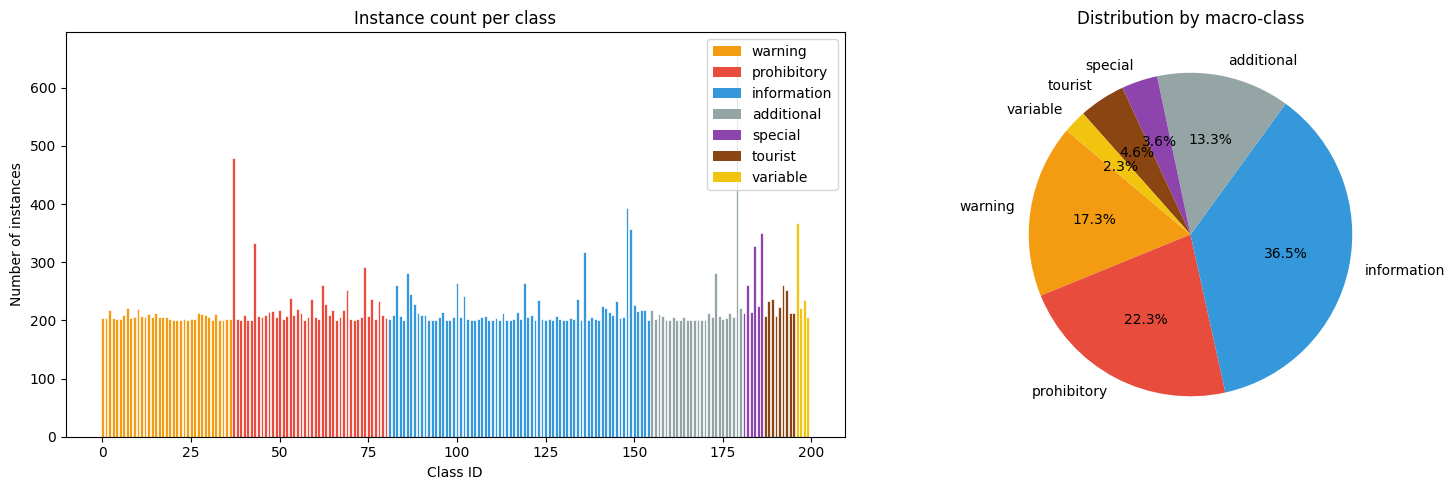

In [17]:
# ── Class distribution plot ───────────────────────────────────────────────────

cmap_hex = {"warning": "#f39c12", "prohibitory": "#e74c3c", "information": "#3498db", "additional": "#95a5a6", "special": "#8e44ad", "tourist": "#8b4513", "variable": "#f1c40f"}

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

bar_colors = [cmap_hex.get(CLASS_TO_MACRO.get(i, "other"), "#95a5a6") for i in range(NUM_CLASSES)]
axes[0].bar(range(NUM_CLASSES), class_counts, color=bar_colors, edgecolor="white", linewidth=0.5)
axes[0].set_xlabel("Class ID")
axes[0].set_ylabel("Number of instances")
axes[0].set_title("Instance count per class")
axes[0].legend(handles=[Patch(facecolor=v, label=k) for k, v in cmap_hex.items()], loc="upper right")

macro_counts = {k: class_counts[v].sum() for k, v in MACRO_CLASSES.items()}
axes[1].pie(macro_counts.values(), labels=macro_counts.keys(),
            colors=[cmap_hex[k] for k in macro_counts],
            autopct="%1.1f%%", startangle=140)
axes[1].set_title("Distribution by macro-class")

plt.tight_layout()
plt.savefig(RESULTS_DIR / "class_distribution.png", dpi=150)
plt.show()

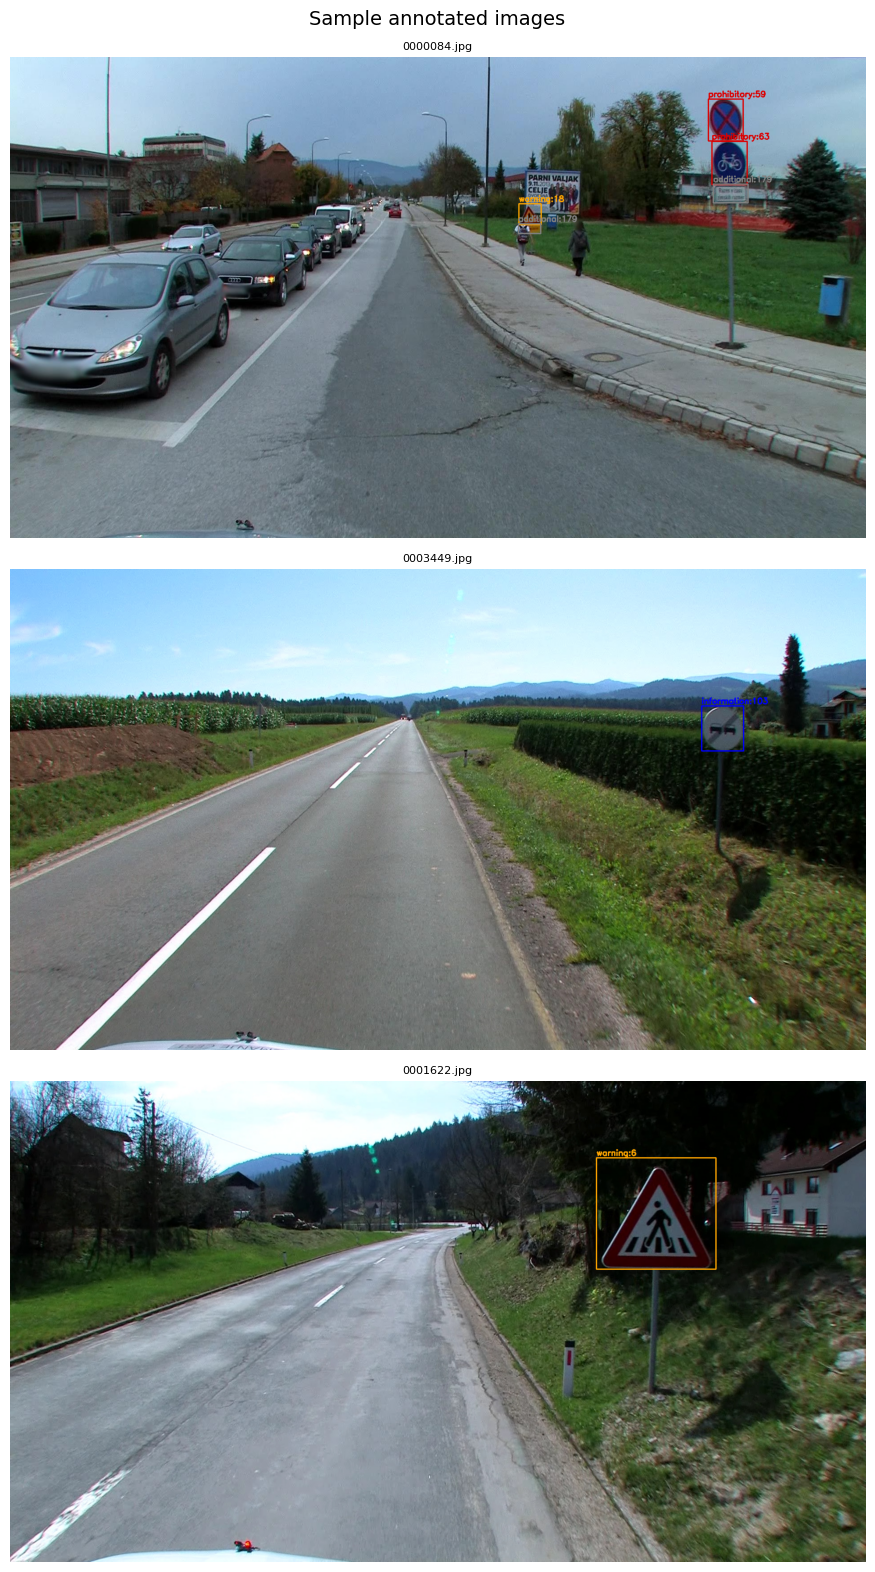

In [17]:
# ── Sample images with bounding boxes from ground truth labels ────────────────────────────────────────
def draw_boxes(img_path, label_path):
    img = cv2.imread(str(img_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]
    if label_path.exists():
        with open(label_path) as f:
            for line in f:
                parts = line.strip().split()
                if not parts:
                    continue
                cid, xc, yc, bw, bh = int(float(parts[0])), float(parts[1]), float(parts[2]), float(parts[3]), float(parts[4])
                x1 = int((xc - bw/2) * w); y1 = int((yc - bh/2) * h)
                x2 = int((xc + bw/2) * w); y2 = int((yc + bh/2) * h)
                macro = CLASS_TO_MACRO.get(cid)
                color = MACRO_COLORS[macro]
                cv2.rectangle(img, (x1, y1), (x2, y2), color, 2)
                cv2.putText(img, f"{macro}:{cid}", (x1, max(y1-5, 0)),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.6, color, 2)
    return img

# Select three specific images by filename and draw ground truth boxes
TARGET_IMAGES = ["0000084.jpg", "0003449.jpg", "0001622.jpg"]
samples = df[df["image"].apply(lambda p: p.name in TARGET_IMAGES)]

samples = samples.set_index(samples["image"].apply(lambda p: p.name)).loc[TARGET_IMAGES].reset_index(drop=True)

fig, axes = plt.subplots(3, 1, figsize=(10, 16))
for ax, (_, row) in zip(axes.flat, samples.iterrows()):
    ax.imshow(draw_boxes(row["image"], row["label"]))
    ax.axis("off")
    ax.set_title(row["image"].name, fontsize=8)
plt.suptitle("Sample annotated images", fontsize=14)
plt.tight_layout()
plt.subplots_adjust(top=0.95)
plt.show()

---
## 5. K-Fold Split Generation <a id='5-splits'></a>

- **Multi-label Stratification**: Since each image can contain multiple traffic signs simultaneously (multi-label), we use multi-label stratification algorithms (`MultilabelStratifiedShuffleSplit` and `MultilabelStratifiedKFold`). This ensures that the percentage distribution of the different traffic sign classes (including the rarest ones) remains balanced and consistent across the training, validation, and test sets, avoiding imbalances during training and evaluation.
- Fixed **test set (15%)** — identical across all models and all phases
- **5 stratified folds** on the remaining 85%, used for training and validation


In [ ]:
# ── Multi-label K-Fold Stratification ────────────────────────────────────────

# Dataset split
K_FOLDS    = 5
TEST_RATIO = 0.15

# Phase 1: Generating Multi-Hot matrix (Y) and image array (X)
label_files = glob.glob(os.path.join(LABELS_DIR, "*.txt"))
X, Y = [], []
for label_path in label_files:
    base_name = os.path.splitext(os.path.basename(label_path))[0]
    X.append(base_name)
    y_vector = np.zeros(NUM_CLASSES, dtype=int)
    with open(label_path, "r") as f:
        for line in f:
            parts = line.strip().split()
            if parts:
                class_id = int(parts[0])
                if 0 <= class_id < NUM_CLASSES:
                    y_vector[class_id] = 1
    Y.append(y_vector)
X = np.array(X)
Y = np.array(Y)

# Phase 2: Isolating the pure Test Set (15%)
msss = MultilabelStratifiedShuffleSplit(n_splits=1, test_size=TEST_RATIO, random_state=SEED)
for train_val_index, test_index in msss.split(X, Y):
    X_train_val, X_test = X[train_val_index], X[test_index]
    Y_train_val, Y_test = Y[train_val_index], Y[test_index]

test_txt_path = os.path.join(SPLITS_DIR, "test.txt")
with open(test_txt_path, "w") as f:
    for item in X_test:
        img_path = os.path.join(IMAGES_DIR, f"{item}.jpg")
        f.write(f"{img_path}\n")

# Phase 3: 5-Fold Cross Validation on the remaining 85% of the dataset and YAML generation
mskf = MultilabelStratifiedKFold(n_splits=K_FOLDS, shuffle=True, random_state=SEED)
for fold, (train_index, val_index) in enumerate(mskf.split(X_train_val, Y_train_val)):
    X_train, X_val = X_train_val[train_index], X_train_val[val_index]
    
    fold_dir = os.path.join(SPLITS_DIR, f"fold_{fold}")
    os.makedirs(fold_dir, exist_ok=True)
    
    train_txt_path = os.path.join(fold_dir, "train.txt")
    val_txt_path = os.path.join(fold_dir, "val.txt")
    
    with open(train_txt_path, "w") as f:
        for item in X_train:
            f.write(f"{os.path.join(IMAGES_DIR, f'{item}.jpg')}\n")
            
    with open(val_txt_path, "w") as f:
        for item in X_val:
            f.write(f"{os.path.join(IMAGES_DIR, f'{item}.jpg')}\n")
            
    yaml_dict = {
        "path": str(DATASET_DIR),
        "train": str(train_txt_path),
        "val": str(val_txt_path),
        "test": str(test_txt_path),
        "nc": int(NUM_CLASSES),
        "names": CLASS_NAMES,
    }
    
    yaml_path = os.path.join(fold_dir, "data.yaml")
    with open(yaml_path, "w") as f:
        yaml.dump(yaml_dict, f, sort_keys=False)
        
    print(f"  Fold {fold}: Train={len(X_train)} img | Val={len(X_val)} img. | YAML generated: {yaml_path}")

  Fold 0: Train=9521 img | Val=2360 img. | YAML generated: ../splits/fold_0/data.yaml
  Fold 1: Train=9520 img | Val=2361 img. | YAML generated: ../splits/fold_1/data.yaml
  Fold 2: Train=9464 img | Val=2417 img. | YAML generated: ../splits/fold_2/data.yaml
  Fold 3: Train=9505 img | Val=2376 img. | YAML generated: ../splits/fold_3/data.yaml
  Fold 4: Train=9514 img | Val=2367 img. | YAML generated: ../splits/fold_4/data.yaml


---
## 6. Phase 1 — YOLO Variant Comparison <a id='6-phase1'></a>

**Goal:** identify the best YOLO variant (nano → xlarge) considering the accuracy/speed trade-off.  
**Strategy:** train all 5 variants with default hyperparameters on **fold 0 only**.  
We log mAP50, mAP50-95, inference time and model size to support the choice.

In [18]:
# ── Phase 1 config ────────────────────────────────────────────────────────────
PHASE1_VARIANTS = ["yolov8n", "yolov8s", "yolov8m", "yolov8l", "yolov8x"]

PHASE1_DEFAULTS = {
    "epochs":   50,     # max epochs — early stopping will likely kick in before
    "batch":    16,
    "lr0":      4.9e-5,
    "patience": 15,
}

PHASE1_FOLD    = 0
PHASE1_DATA    = SPLITS_DIR / f"fold_{PHASE1_FOLD}" / "data.yaml"
PHASE1_RESULTS = RESULTS_DIR / "phase1_results.json"

print(f"Variants to compare : {PHASE1_VARIANTS}")
print(f"Training fold       : fold {PHASE1_FOLD}")
print(f"Max epochs          : {PHASE1_DEFAULTS['epochs']} (early stopping patience={PHASE1_DEFAULTS['patience']})")

Variants to compare : ['yolov8n', 'yolov8s', 'yolov8m', 'yolov8l', 'yolov8x']
Training fold       : fold 0
Max epochs          : 50 (early stopping patience=15)


In [ ]:
# ── Phase 1 training loop ─────────────────────────────────────────────────────
# Results are written to JSON after each run

phase1_results = []

for variant in PHASE1_VARIANTS:
    run_name = f"phase1_{variant}_fold{PHASE1_FOLD}"
    save_dir = CHECKPOINTS_DIR / "phase1" / run_name
    print(f"\n{'='*60}\nPhase 1 — {variant}\n{'='*60}")

    model = YOLO(f"{variant}.pt")

    results = model.train(
        data     = str(PHASE1_DATA),
        epochs   = PHASE1_DEFAULTS["epochs"],
        batch    = PHASE1_DEFAULTS["batch"],
        lr0      = PHASE1_DEFAULTS["lr0"],
        patience = PHASE1_DEFAULTS["patience"],
        project  = str(save_dir.parent),
        name     = run_name,
        exist_ok = True,
        device   = 0 if torch.cuda.is_available() else "cpu",
        seed     = SEED,
        save     = True,
        plots    = True,
        optimizer = "AdamW"
    )
    metrics = results.results_dict

    # ── Measure inference time (ms/image) on 50 images ───────────────────────
    val_images = list(IMAGES_DIR.rglob("*.jpg"))[:50]
    _ = model.predict(str(val_images[0]), verbose=False)   # warm-up
    t0 = time.time()
    for p in val_images:
        model.predict(str(p), verbose=False)
    inf_ms = (time.time() - t0) / len(val_images) * 1000

    weight_path = save_dir / "weights" / "best.pt"
    model_mb    = round(weight_path.stat().st_size / 1e6, 1) if weight_path.exists() else None

    entry = {
        "variant":      variant,
        "mAP50":        metrics.get("metrics/mAP50(B)"),
        "mAP50-95":     metrics.get("metrics/mAP50-95(B)"),
        "precision":    metrics.get("metrics/precision(B)"),
        "recall":       metrics.get("metrics/recall(B)"),
        "inf_ms":       round(inf_ms, 2),
        "model_mb":     model_mb,
        "best_weights": str(weight_path),
    }
    phase1_results.append(entry)

    # Save after every run
    with open(PHASE1_RESULTS, "w") as f:
        json.dump(phase1_results, f, indent=2)
    print(f"  mAP@50={entry['mAP50']:.4f} | inf={entry['inf_ms']}ms | size={entry['model_mb']}MB")

print(f"\nPhase 1 complete. Results → {PHASE1_RESULTS}")


Phase 1 — yolov8n


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 6.25M/6.25M [00:00<00:00, 79.4MB/s]


New https://pypi.org/project/ultralytics/8.4.70 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.3.27 🚀 Python-3.10.12 torch-2.5.1+cu124 CUDA:0 (NVIDIA A100-SXM4-80GB, 81051MiB)
engine/trainer: task=detect, mode=train, model=yolov8n.pt, data=../splits/fold_0/data.yaml, epochs=50, time=None, patience=15, batch=16, imgsz=640, save=True, save_period=-1, cache=False, device=0, workers=8, project=../checkpoints/phase1, name=phase1_yolov8n_fold0, exist_ok=True, pretrained=True, optimizer=auto, verbose=True, seed=42, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=Fa

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 22.2M/22.2M [00:01<00:00, 22.3MB/s]
E0000 00:00:1781773219.261597     336 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1781773219.267789     336 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


Overriding model.yaml nc=80 with nc=200

                   from  n    params  module                                       arguments                     
  0                  -1  1       464  ultralytics.nn.modules.conv.Conv             [3, 16, 3, 2]                 
  1                  -1  1      4672  ultralytics.nn.modules.conv.Conv             [16, 32, 3, 2]                
  2                  -1  1      7360  ultralytics.nn.modules.block.C2f             [32, 32, 1, True]             
  3                  -1  1     18560  ultralytics.nn.modules.conv.Conv             [32, 64, 3, 2]                
  4                  -1  2     49664  ultralytics.nn.modules.block.C2f             [64, 64, 2, True]             
  5                  -1  1     73984  ultralytics.nn.modules.conv.Conv             [64, 128, 3, 2]               
  6                  -1  2    197632  ultralytics.nn.modules.block.C2f             [128, 128, 2, True]           
  7                  -1  1    295424  ultralyti

...

                   all       2391       7461      0.927      0.886      0.932      0.892

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


      50/50      13.2G     0.2393     0.1746     0.7762          5        640: 100%|██████████| 598/598 [01:55<00:00,  5.17it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 75/75 [00:10<00:00,  7.21it/s]


                   all       2391       7461      0.927      0.888      0.932      0.893

50 epochs completed in 1.825 hours.
Optimizer stripped from ../checkpoints/phase1/phase1_yolov8x_fold0/weights/last.pt, 137.1MB
Optimizer stripped from ../checkpoints/phase1/phase1_yolov8x_fold0/weights/best.pt, 137.1MB

Validating ../checkpoints/phase1/phase1_yolov8x_fold0/weights/best.pt...
Ultralytics 8.3.27 🚀 Python-3.10.12 torch-2.5.1+cu124 CUDA:0 (NVIDIA A100-SXM4-80GB, 81051MiB)
Model summary (fused): 268 layers, 68,316,168 parameters, 0 gradients, 258.5 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 75/75 [00:11<00:00,  6.74it/s]


                   all       2391       7461      0.928      0.892      0.934      0.893
      Curva a sinistra         34         34      0.975      0.912      0.974       0.94
        Curva a destra         34         34       0.96      0.971      0.987      0.972
Dosso / gobba sulla strada         36         36          1      0.909      0.982      0.945
 Strada sdrucciolevole         34         34      0.909      0.971      0.987      0.959
Caduta massi (da destra)         34         34      0.943      0.912      0.969      0.938
Caduta massi (da sinistra)         34         34      0.909       0.88      0.948       0.93
Attraversamento pedonale         36         36      0.809      0.972      0.981      0.938
               Bambini         38         38      0.965       0.72      0.926       0.82
              Ciclisti         35         37          1      0.866      0.978      0.946
Animali domestici in strada         34         34      0.988          1      0.995      0.971
Faun

Phase 1 — Variant comparison
variant    mAP50  mAP50-95  precision   recall  inf_ms  model_mb
yolov8n 0.711131  0.650746   0.700977 0.676537   14.94       7.0
yolov8s 0.846004  0.786769   0.831704 0.792972   14.99      22.7
yolov8m 0.907890  0.857645   0.896302 0.857899   16.49      52.3
yolov8l 0.929531  0.887357   0.922760 0.883680   18.08      88.0
yolov8x 0.934308  0.892821   0.927656 0.891575   20.46     137.1


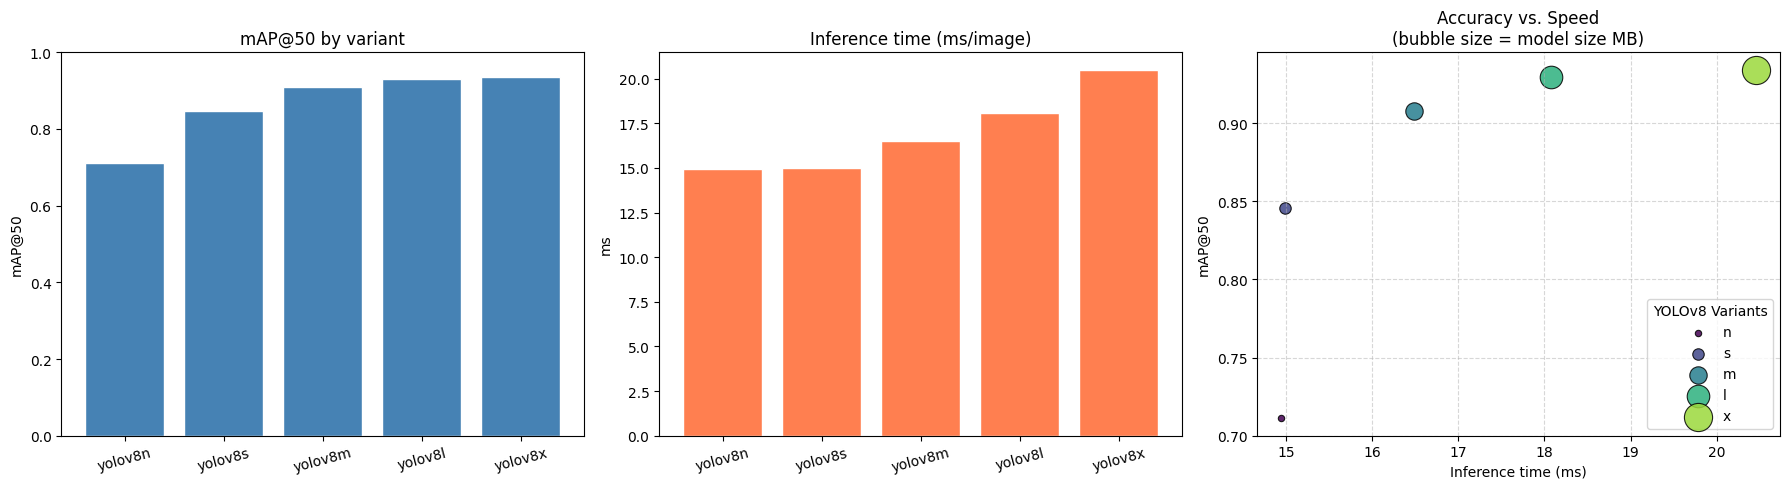

In [19]:
# ── Phase 1 comparison table & plots ─────────────────────────────────────────

with open(PHASE1_RESULTS) as f:
    phase1_results = json.load(f)

p1_df = pd.DataFrame(phase1_results)
print("Phase 1 — Variant comparison")
print(
    p1_df[
        [
            "variant",
            "mAP50",
            "mAP50-95",
            "precision",
            "recall",
            "inf_ms",
            "model_mb",
        ]
    ].to_string(index=False)
)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. First Plot: mAP@50 bar chart by YOLOv8 variant
axes[0].bar(
    p1_df["variant"], p1_df["mAP50"], color="steelblue", edgecolor="white"
)
axes[0].set_title("mAP@50 by variant")
axes[0].set_ylabel("mAP@50")
axes[0].set_ylim(0, 1)
axes[0].tick_params(axis="x", rotation=15)

# 2. Second Plot: Inference latency (ms per image) bar chart
axes[1].bar(p1_df["variant"], p1_df["inf_ms"], color="coral", edgecolor="white")
axes[1].set_title("Inference time (ms/image)")
axes[1].set_ylabel("ms")
axes[1].tick_params(axis="x", rotation=15)

# 3. Third Plot: Trade-off bubble chart (Accuracy vs. Speed)
colors = plt.cm.viridis(np.linspace(0, 0.85, len(p1_df)))

for i, row in p1_df.iterrows():
    axes[2].scatter(
        row["inf_ms"],
        row["mAP50"],
        s=row["model_mb"] * 3,  # Bubble size represents the model weight size in MB
        color=colors[i],
        label=row["variant"].replace("yolov8", ""),
        edgecolors="k",
        linewidths=0.8,
        alpha=0.85,
    )

axes[2].set_xlabel("Inference time (ms)")
axes[2].set_ylabel("mAP@50")
axes[2].set_title("Accuracy vs. Speed\n(bubble size = model size MB)")

axes[2].legend(title="YOLOv8 Variants", loc="lower right", frameon=True)
axes[2].grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.savefig(RESULTS_DIR / "phase1_comparison.png", dpi=150)
plt.show()

In [20]:
# ── Set the variant choice  ─────────────────────────────────────────
# After reviewing the table and plots above, choose one or more variants to carry
# forward to Phase 2. Consider mAP50, inference time and model size together.

SELECTED_VARIANTS = ["yolov8m"] 

print(f"Selected variants for Phase 2: {SELECTED_VARIANTS}")

Selected variants for Phase 2: ['yolov8m']


---
## 7. Phase 2 — Hyperparameter Grid Search <a id='7-phase2'></a>

**Goal:** find the best hyperparameter configuration for the selected variant(s).  
**Strategy:** 4-point grid search on **fold 0 only**.

| Parameter | Values | Rationale |
|---|---|---|
| `lr0` | 4.9e-5, 1e-3 | conservative vs. aggressive fine-tuning (weights are already pretrained on COCO) |
| `freeze` | None, 10 | full fine-tune vs. freeze first 10 backbone layers |

Epochs are **not** in the grid — we fix a high max and rely on early stopping.

In [21]:
# ── Phase 2 config ────────────────────────────────────────────────────────────
PHASE2_GRID = [
    {"lr0": 0.49e-4, "freeze": None},
    {"lr0": 0.49e-4, "freeze": 10},
    {"lr0": 1e-3, "freeze": None},
    {"lr0": 1e-3, "freeze": 10},
]

PHASE2_EPOCHS   = 50
PHASE2_BATCH_SIZE = 16
PHASE2_PATIENCE = 15
PHASE2_FOLD     = 0
PHASE2_DATA     = SPLITS_DIR / f"fold_{PHASE2_FOLD}" / "data.yaml"
PHASE2_RESULTS  = RESULTS_DIR / "phase2_results.json"

print(f"Selected variants : {SELECTED_VARIANTS}")
print(f"Grid size         : {len(PHASE2_GRID)} configs")
print(f"Total runs        : {len(SELECTED_VARIANTS) * len(PHASE2_GRID)}")

Selected variants : ['yolov8m']
Grid size         : 4 configs
Total runs        : 4


In [ ]:
# ── Phase 2 training loop ─────────────────────────────────────────────────────
phase2_results = []

for variant in SELECTED_VARIANTS:
    for cfg_idx, hparams in enumerate(PHASE2_GRID):
        run_name = f"phase2_{variant}_cfg{cfg_idx}"
        save_dir = CHECKPOINTS_DIR / "phase2" / run_name
        print(f"\n{'='*60}")
        print(f"Phase 2 — {variant} | cfg {cfg_idx}: {hparams}")
        print(f"{'='*60}")

        model = YOLO(f"{variant}.pt")

        train_kwargs = dict(
            data     = str(PHASE2_DATA),
            epochs   = PHASE2_EPOCHS,
            batch    = PHASE2_BATCH_SIZE,
            lr0      = hparams["lr0"],
            patience = PHASE2_PATIENCE,
            project  = str(save_dir.parent),
            name     = run_name,
            exist_ok = True,
            device   = 0 if torch.cuda.is_available() else "cpu",
            seed     = SEED,
            save     = True,
            plots    = True,
            optimizer = "AdamW"
        )
        if hparams["freeze"] is not None:
            train_kwargs["freeze"] = hparams["freeze"]

        results = model.train(**train_kwargs)
        metrics = results.results_dict

        entry = {
            "variant":      variant,
            "cfg_idx":      cfg_idx,
            "lr0":          hparams["lr0"],
            "freeze":       hparams["freeze"],
            "batch":        PHASE2_BATCH_SIZE,
            "mAP50":        metrics.get("metrics/mAP50(B)"),
            "mAP50-95":     metrics.get("metrics/mAP50-95(B)"),
            "precision":    metrics.get("metrics/precision(B)"),
            "recall":       metrics.get("metrics/recall(B)"),
            "best_weights": str(save_dir / "weights" / "best.pt"),
        }
        phase2_results.append(entry)

        # Save after every run
        with open(PHASE2_RESULTS, "w") as f:
            json.dump(phase2_results, f, indent=2)
        print(f"  mAP@50={entry['mAP50']:.4f}")

print(f"\nPhase 2 complete. Results: {PHASE2_RESULTS}")


Phase 2 — yolov8m | cfg 2: {'lr0': 0.001, 'freeze': None}
New https://pypi.org/project/ultralytics/8.4.71 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.3.27 🚀 Python-3.10.12 torch-2.5.1+cu124 CUDA:0 (NVIDIA A100-SXM4-80GB, 81051MiB)
engine/trainer: task=detect, mode=train, model=yolov8m.pt, data=../splits/fold_0/data.yaml, epochs=50, time=None, patience=15, batch=16, imgsz=640, save=True, save_period=-1, cache=False, device=0, workers=8, project=../checkpoints/phase2, name=phase2_yolov8m_cfg2, exist_ok=True, pretrained=True, optimizer=AdamW, verbose=True, seed=42, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augme

train: Scanning ../dataset/labels... 9553 images, 0 backgrounds, 0 corrupt: 100%|██████████| 9553/9553 [00:03<00:00, 2660.15it/s]


train: New cache created: ../dataset/labels.cache


val: Scanning ../dataset/labels... 2391 images, 0 backgrounds, 0 corrupt: 100%|██████████| 2391/2391 [00:00<00:00, 2574.33it/s]

val: New cache created: ../dataset/labels.cache


...

                   all       2391       7461      0.846      0.812      0.867      0.812

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


      50/50       5.9G     0.3505     0.3645     0.7962          5        640: 100%|██████████| 598/598 [00:44<00:00, 13.56it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 75/75 [00:07<00:00, 10.24it/s]


                   all       2391       7461      0.851      0.812      0.868      0.813

50 epochs completed in 0.750 hours.
Optimizer stripped from ../checkpoints/phase2/phase2_yolov8m_cfg3/weights/last.pt, 52.3MB
Optimizer stripped from ../checkpoints/phase2/phase2_yolov8m_cfg3/weights/best.pt, 52.3MB

Validating ../checkpoints/phase2/phase2_yolov8m_cfg3/weights/best.pt...
Ultralytics 8.3.27 🚀 Python-3.10.12 torch-2.5.1+cu124 CUDA:0 (NVIDIA A100-SXM4-80GB, 81051MiB)
Model summary (fused): 218 layers, 25,955,560 parameters, 0 gradients, 79.3 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 75/75 [00:08<00:00,  9.00it/s]


                   all       2391       7461      0.852      0.815      0.872      0.818
      Curva a sinistra         34         34      0.862      0.736      0.904      0.862
        Curva a destra         34         34      0.779      0.828      0.885      0.853
Dosso / gobba sulla strada         36         36       0.91       0.75      0.905      0.849
 Strada sdrucciolevole         34         34       0.83      0.794      0.935      0.911
Caduta massi (da destra)         34         34      0.963      0.776      0.909      0.861
Caduta massi (da sinistra)         34         34      0.724      0.912      0.867      0.831
Attraversamento pedonale         36         36      0.942      0.944      0.972      0.935
               Bambini         38         38      0.952      0.526      0.748      0.617
              Ciclisti         35         37      0.963      0.701      0.884      0.845
Animali domestici in strada         34         34      0.969      0.917      0.974      0.943
Faun

Phase 2 — Hyperparameter grid search results
variant  cfg_idx     lr0  freeze  batch    mAP50  mAP50-95  precision   recall
yolov8m        0 0.00005     NaN     16 0.907890  0.857645   0.896302 0.857899
yolov8m        1 0.00005    10.0     16 0.840512  0.789253   0.822652 0.786233
yolov8m        2 0.00100     NaN     16 0.929030  0.883630   0.925425 0.883497
yolov8m        3 0.00100    10.0     16 0.871781  0.817622   0.852155 0.815447


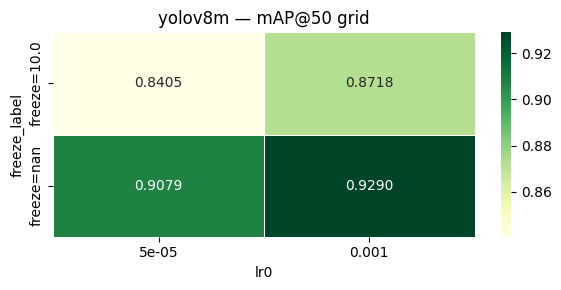

In [22]:
# ── Phase 2 results table & heatmaps ─────────────────────────────────────────

with open(PHASE2_RESULTS) as f:
    phase2_results = json.load(f)

p2_df = pd.DataFrame(phase2_results)
print("Phase 2 — Hyperparameter grid search results")
print(p2_df[["variant", "cfg_idx", "lr0", "freeze", "batch",
             "mAP50", "mAP50-95", "precision", "recall"]].to_string(index=False))

# mAP50 heatmap per variant: rows=freeze, cols=lr0
for variant in SELECTED_VARIANTS:
    sub = p2_df[p2_df["variant"] == variant].copy()
    sub["freeze_label"] = sub["freeze"].apply(lambda x: f"freeze={x}" if x else "no freeze")
    pivot = sub.pivot_table(index="freeze_label", columns="lr0", values="mAP50")
    fig, ax = plt.subplots(figsize=(6, 3))
    sns.heatmap(pivot, annot=True, fmt=".4f", cmap="YlGn", ax=ax, linewidths=0.5)
    ax.set_title(f"{variant} — mAP@50 grid")
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / f"phase2_heatmap_{variant}.png", dpi=150)
    plt.show()

In [23]:
# ── Set hyperparameter choice ───────────────────────────────────
# After reviewing the table and heatmap above, set the best variant and config.
# All subsequent sections use these values automatically.

FINAL_VARIANT = "yolov8m"   
FINAL_CFG_IDX = 2          

# Retrieve the chosen config automatically
final_cfg = next(r for r in phase2_results
                 if r["variant"] == FINAL_VARIANT and r["cfg_idx"] == FINAL_CFG_IDX)

print(f"Final variant : {FINAL_VARIANT}")
print(f"Final config  : lr0={final_cfg['lr0']} | freeze={final_cfg['freeze']}")

Final variant : yolov8m
Final config  : lr0=0.001 | freeze=None


---
## 8. Phase 3 — Cross-Validation on Best Config <a id='8-phase3'></a>

**Goal:** reliable performance estimate of the chosen model and config (on 80 epochs).  
**Strategy:** train on **all K folds**. Final reported metrics are **mean ± std** across folds.

In [24]:
PHASE3_RESULTS = RESULTS_DIR / "phase3_results.json"
phase3_results = []
PHASE3_EPOCHS = 80

In [ ]:
for fold_idx in range(K_FOLDS):
    run_name  = f"phase3_{FINAL_VARIANT}_cfg{FINAL_CFG_IDX}_fold{fold_idx}"
    save_dir  = CHECKPOINTS_DIR / "phase3" / run_name
    data_yaml = SPLITS_DIR / f"fold_{fold_idx}" / "data.yaml"

    print(f"\n{'='*60}")
    print(f"Phase 3 — {FINAL_VARIANT} | fold {fold_idx}/{K_FOLDS-1}")
    print(f"{'='*60}")

    model = YOLO(f"{FINAL_VARIANT}.pt")

    train_kwargs = dict(
        data     = str(data_yaml),
        epochs   = PHASE3_EPOCHS,
        batch    = PHASE2_BATCH_SIZE,
        lr0      = final_cfg["lr0"],
        patience = PHASE2_PATIENCE,
        project  = str(save_dir.parent),
        name     = run_name,
        exist_ok = True,
        device   = 0 if torch.cuda.is_available() else "cpu",
        seed     = SEED,
        save     = True,
        plots    = True,
        optimizer = "AdamW"
    )
    if final_cfg["freeze"] is not None:
        train_kwargs["freeze"] = final_cfg["freeze"]

    results = model.train(**train_kwargs)
    metrics = results.results_dict

    entry = {
        "fold":         fold_idx,
        "mAP50":        metrics.get("metrics/mAP50(B)"),
        "mAP50-95":     metrics.get("metrics/mAP50-95(B)"),
        "precision":    metrics.get("metrics/precision(B)"),
        "recall":       metrics.get("metrics/recall(B)"),
        "best_weights": str(save_dir / "weights" / "best.pt"),
    }
    phase3_results.append(entry)

    with open(PHASE3_RESULTS, "w") as f:
        json.dump(phase3_results, f, indent=2)
    print(f"  Fold {fold_idx} mAP@50 = {entry['mAP50']:.4f}")


Phase 3 — yolov8m | fold 1/4
New https://pypi.org/project/ultralytics/8.4.71 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.3.27 🚀 Python-3.10.12 torch-2.5.1+cu124 CUDA:0 (NVIDIA A100-SXM4-80GB, 81051MiB)
engine/trainer: task=detect, mode=train, model=yolov8m.pt, data=../splits/fold_1/data.yaml, epochs=80, time=None, patience=15, batch=16, imgsz=640, save=True, save_period=-1, cache=False, device=0, workers=8, project=../checkpoints/phase3, name=phase3_yolov8m_cfg2_fold1, exist_ok=True, pretrained=True, optimizer=AdamW, verbose=True, seed=42, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=

train: Scanning ../dataset/labels... 9554 images, 0 backgrounds, 0 corrupt: 100%|██████████| 9554/9554 [00:03<00:00, 2718.54it/s]


train: New cache created: ../dataset/labels.cache


val: Scanning ../dataset/labels... 2390 images, 0 backgrounds, 0 corrupt: 100%|██████████| 2390/2390 [00:00<00:00, 2548.91it/s]

val: New cache created: ../dataset/labels.cache


...

      80/80      13.4G     0.2768     0.2241     0.7827         43        640: 100%|██████████| 596/596 [01:04<00:00,  9.23it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 76/76 [00:07<00:00, 10.47it/s]


                   all       2412       7456      0.933      0.892      0.935      0.891

80 epochs completed in 1.675 hours.
Optimizer stripped from ../checkpoints/phase3/phase3_yolov8m_cfg2_fold4/weights/last.pt, 52.3MB
Optimizer stripped from ../checkpoints/phase3/phase3_yolov8m_cfg2_fold4/weights/best.pt, 52.3MB

Validating ../checkpoints/phase3/phase3_yolov8m_cfg2_fold4/weights/best.pt...
Ultralytics 8.3.27 🚀 Python-3.10.12 torch-2.5.1+cu124 CUDA:0 (NVIDIA A100-SXM4-80GB, 81051MiB)
Model summary (fused): 218 layers, 25,955,560 parameters, 0 gradients, 79.3 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 76/76 [00:08<00:00,  9.26it/s]


                   all       2412       7456      0.936      0.889      0.935      0.891
      Curva a sinistra         34         34      0.983      0.912      0.972      0.956
        Curva a destra         35         35      0.991      0.971      0.987      0.972
Dosso / gobba sulla strada         37         37       0.97       0.87       0.99      0.924
 Strada sdrucciolevole         35         35       0.97       0.92      0.986      0.963
Caduta massi (da destra)         34         35      0.944      0.829      0.917      0.889
Caduta massi (da sinistra)         34         34      0.915      0.944      0.984      0.954
Attraversamento pedonale         35         35      0.957      0.943      0.989       0.93
               Bambini         37         37          1      0.782      0.868      0.819
              Ciclisti         34         34          1      0.869      0.972      0.945
Animali domestici in strada         35         35          1      0.901      0.963      0.935
Faun

63

In [25]:
# ── Summary statistics ────────────────────────────────────────────────────────

with open(PHASE3_RESULTS) as f:
    phase3_results = json.load(f)
p3_df = pd.DataFrame(phase3_results)

print("\n── Cross-validation summary ──────────────────────────────")
for metric in ["mAP50", "mAP50-95", "precision", "recall"]:
    print(f"  {metric:12s}: {p3_df[metric].mean():.4f} ± {p3_df[metric].std():.4f}")

# Save best fold weights path for downstream use
BEST_YOLO_WEIGHTS = p3_df.loc[p3_df["mAP50"].idxmax(), "best_weights"]
print(f"\nBest fold weights → {BEST_YOLO_WEIGHTS}")
_ = (RESULTS_DIR / "best_yolo_weights.txt").write_text(BEST_YOLO_WEIGHTS)


── Cross-validation summary ──────────────────────────────
  mAP50       : 0.9318 ± 0.0028
  mAP50-95    : 0.8877 ± 0.0035
  precision   : 0.9294 ± 0.0051
  recall      : 0.8910 ± 0.0054

Best fold weights → ../checkpoints/phase3/phase3_yolov8m_cfg2_fold0/weights/best.pt


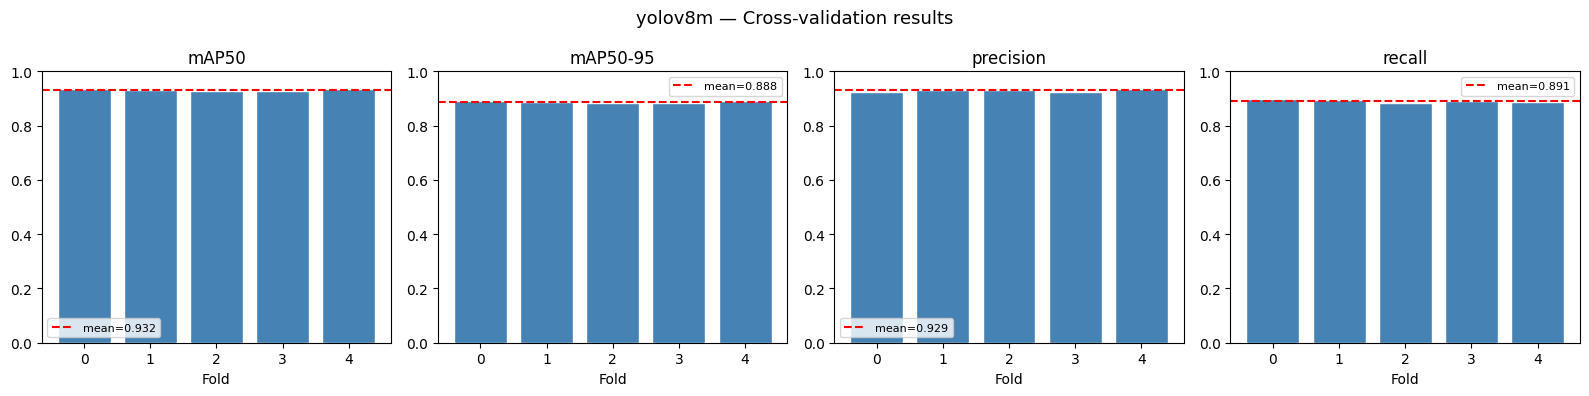

In [26]:
# ── Cross-validation results plot ─────────────────────────────────────────────

metrics_to_plot = ["mAP50", "mAP50-95", "precision", "recall"]
fig, axes = plt.subplots(1, len(metrics_to_plot), figsize=(16, 4))

for ax, metric in zip(axes, metrics_to_plot):
    ax.bar(p3_df["fold"], p3_df[metric], color="steelblue", edgecolor="white")
    ax.axhline(p3_df[metric].mean(), color="red", linestyle="--",
               label=f"mean={p3_df[metric].mean():.3f}")
    ax.set_title(metric)
    ax.set_xlabel("Fold")
    ax.set_ylim(0, 1)
    ax.legend(fontsize=8)

plt.suptitle(f"{FINAL_VARIANT} — Cross-validation results", fontsize=13)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "phase3_crossval.png", dpi=150)
plt.show()

---
## 9. YOLO Final Evaluation <a id='9-yolo-eval'></a>

In [27]:
# ── Reload best weights (the one related to the best fold above) ────────────────────
with open(RESULTS_DIR / "best_yolo_weights.txt") as f:
    BEST_YOLO_WEIGHTS = f.read().strip()

best_model = YOLO(BEST_YOLO_WEIGHTS)

In [28]:
# ── Yolo final evaluation on the hold-out test set  ────────────────────
test_yaml    = SPLITS_DIR / "fold_0" / "data.yaml"   # test set is identical across folds
test_metrics = best_model.val(
    data=str(test_yaml),
    split="test",
    device="cpu" if DEVICE.type == "cpu" else 0
)

Ultralytics 8.3.27 🚀 Python-3.10.12 torch-2.5.1+cu124 CUDA:0 (NVIDIA A100-SXM4-80GB, 81051MiB)
Model summary (fused): 218 layers, 25,955,560 parameters, 0 gradients, 79.3 GFLOPs


val: Scanning ../dataset/labels.cache... 2085 images, 0 backgrounds, 0 corrupt: 100%|██████████| 2085/2085 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 131/131 [00:08<00:00, 14.91it/s]


                   all       2085       6635      0.933      0.887      0.932      0.892
      Curva a sinistra         32         33      0.935      0.876      0.977      0.951
        Curva a destra         30         31      0.891      0.935      0.977       0.96
Dosso / gobba sulla strada         36         36          1      0.864      0.894      0.868
 Strada sdrucciolevole         31         31      0.967      0.948      0.993      0.968
Caduta massi (da destra)         32         33      0.974      0.879      0.991      0.947
Caduta massi (da sinistra)         30         30      0.894      0.967      0.964      0.945
Attraversamento pedonale         31         31      0.958      0.968      0.989       0.95
               Bambini         33         33       0.96      0.818      0.835      0.789
              Ciclisti         30         30      0.983      0.967      0.985      0.965
Animali domestici in strada         31         32          1      0.959       0.99      0.979
Faun

In [29]:
# ── Test set results ────────────────────
clean_dict = {k.replace('metrics/', ''): v for k, v in test_metrics.results_dict.items()}
df_metrics = pd.DataFrame(list(clean_dict.items()), columns=['Metric', 'Value'])

print("\nTest-set metrics:")
print(df_metrics.to_string(index=False))


Test-set metrics:
      Metric    Value
precision(B) 0.933199
   recall(B) 0.886618
    mAP50(B) 0.931664
 mAP50-95(B) 0.892388
     fitness 0.896315


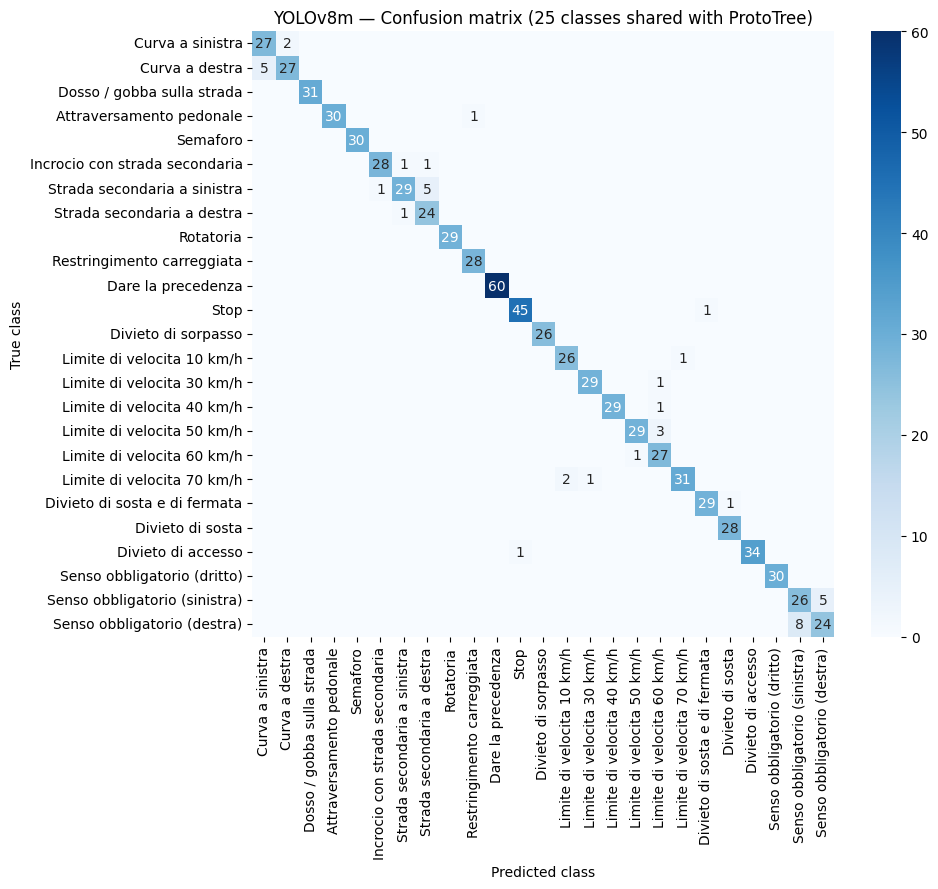

In [30]:
# ── Final Confusion Matrix (only the classes in common with ProtoTree) ────────────────────
cm = test_metrics.confusion_matrix.matrix

# Select only the classes shared with ProtoTree
selected_idx = sorted(SELECTED_CLASSES)

# Extract only the corresponding rows and columns
cm_25 = cm[np.ix_(selected_idx, selected_idx)]
class_names_25 = [CLASS_NAMES[c] for c in selected_idx]

annot_labels = np.where(cm_25 > 0, cm_25.astype(int).astype(str), "")
fig, ax = plt.subplots(figsize=(10, 9))
sns.heatmap(cm_25, annot=annot_labels, fmt="", cmap="Blues",
            xticklabels=class_names_25, yticklabels=class_names_25, ax=ax)

ax.set_xlabel("Predicted class")
ax.set_ylabel("True class")
ax.set_title("YOLOv8m — Confusion matrix (25 classes shared with ProtoTree)")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "yolo_confusion_matrix_25classes.png", dpi=150)
plt.show()

---
## 10. Crop Extraction — Ground Truth → ProtoTree input <a id='10-crops'></a>

Crops for ProtoTree training are extracted directly from the ground truth annotations.

In [31]:
def read_split_list(file_path):
    with open(file_path, "r") as f:
        # extract only the file name (without path, without extension)
        return [Path(line.strip()).stem for line in f if line.strip()]

def extract_and_save_crops(split_name, image_list, images_dir, labels_dir, output_dir):
    print(f"\n[{split_name.upper()}] Starting crop extraction...")
    crops_count = 0
    for base_name in image_list:
        img_paths = glob.glob(os.path.join(images_dir, f"{base_name}.*"))
        if not img_paths: continue
        img_path = img_paths[0]
        label_path = os.path.join(labels_dir, f"{base_name}.txt")
        if not os.path.exists(label_path): continue
        
        img = cv2.imread(img_path)
        if img is None: continue
        img_h, img_w = img.shape[:2]
        
        with open(label_path, "r") as f:
            for i, line in enumerate(f):
                parts = line.strip().split()
                if len(parts) >= 5:
                    class_id = int(parts[0])
                    if class_id not in SELECTED_CLASSES: continue
                    x_center, y_center, w, h = map(float, parts[1:5])
                    x1 = max(0, int((x_center - w / 2) * img_w))
                    y1 = max(0, int((y_center - h / 2) * img_h))
                    x2 = min(img_w, int((x_center + w / 2) * img_w))
                    y2 = min(img_h, int((y_center + h / 2) * img_h))
                    
                    if x2 > x1 and y2 > y1:
                        crop = img[y1:y2, x1:x2]
                        class_dir = os.path.join(output_dir, split_name, str(class_id))
                        os.makedirs(class_dir, exist_ok=True)
                        crop_path = os.path.join(class_dir, f"{base_name}_crop_{i}.jpg")
                        cv2.imwrite(crop_path, crop)
                        crops_count += 1
    print(f"  -> Extracted {crops_count} crops for '{split_name}'.")

BEST_FOLD = p3_df.loc[p3_df["mAP50"].idxmax(), "fold"]

train_list = read_split_list(os.path.join(SPLITS_DIR, f"fold_{BEST_FOLD}", "train.txt"))
val_list   = read_split_list(os.path.join(SPLITS_DIR, f"fold_{BEST_FOLD}", "val.txt"))
test_list = read_split_list(os.path.join(SPLITS_DIR, "test.txt"))

# Merge YOLO's train and validation splits of the best fold into a single training set
# for ProtoTree. Since ProtoTree does not require a validation split during training,
# this maximizes the amount of training samples (crops) available to learn prototypes.
train_list_prototree = train_list + val_list

extract_and_save_crops("test",  test_list,            IMAGES_DIR, LABELS_DIR, CROPS_SPLIT_DIR)
extract_and_save_crops("train", train_list_prototree, IMAGES_DIR, LABELS_DIR, CROPS_SPLIT_DIR)

# Convert the classes to strings to mimic ImageFolder's alphabetical sorting
folder_names = sorted([str(c) for c in SELECTED_CLASSES])

# Save the class mapping (index 0-24 -> original YOLO class_id) into 'class_mapping.json'
mapping = {i: int(c) for i, c in enumerate(folder_names)}
with open(os.path.join(CROPS_SPLIT_DIR, 'class_mapping.json'), 'w') as f:
    json.dump(mapping, f, indent=4)
    
print(f"Saved class_mapping.json with {len(mapping)} classes")



[TEST] Starting crop extraction...
  -> Extracted 872 crops for 'test'.

[TRAIN] Starting crop extraction...
  -> Extracted 4878 crops for 'train'.
Saved class_mapping.json with 25 classes


---
## 11. ProtoTree Training & Visualization <a id='11-prototree'></a>

ProtoTree learns an interpretable binary decision tree where each internal node tests
whether a learned visual prototype is **present** in the input patch.  
Backbone: ResNet50 pretrained on ImageNet.

In [ ]:
# ProtoTree training and evaluation following the official repository guidelines

!python3 ProtoTree/main_tree.py \
    --epochs 100 \
    --log_dir ../checkpoints/prototree \
    --dataset traffic_signs \
    --lr 0.001 --lr_block 0.001 --lr_net 1e-5 \
    --num_features 256 \
    --depth 6 \
    --net resnet50 \
    --freeze_epochs 30 \
    --milestones 60,70,80,90,100

Log dir:  ../checkpoints/prototree
Num classes (k) =  25
Train Epoch 1: 100% 77/77 [00:34<00:00,  2.23it/s, Batch [77/77], Loss: 3.513, Acc: 0.000]
Eval Epoch 1: 100% 14/14 [00:02<00:00,  6.41it/s, Batch [14/14], Acc: 0.000]
Train Epoch 2: 100% 77/77 [00:33<00:00,  2.27it/s, Batch [77/77], Loss: 3.170, Acc: 0.071]
Eval Epoch 2: 100% 14/14 [00:02<00:00,  6.67it/s, Batch [14/14], Acc: 0.000]
Train Epoch 3: 100% 77/77 [00:34<00:00,  2.25it/s, Batch [77/77], Loss: 3.010, Acc: 0.071]
Eval Epoch 3: 100% 14/14 [00:02<00:00,  6.69it/s, Batch [14/14], Acc: 0.000]
Train Epoch 4: 100% 77/77 [00:33<00:00,  2.28it/s, Batch [77/77], Loss: 2.921, Acc: 0.071]
Eval Epoch 4: 100% 14/14 [00:02<00:00,  6.64it/s, Batch [14/14], Acc: 0.000]
Train Epoch 5: 100% 77/77 [00:34<00:00,  2.25it/s, Batch [77/77], Loss: 2.974, Acc: 0.000]
Eval Epoch 5: 100% 14/14 [00:02<00:00,  6.31it/s, Batch [14/14], Acc: 0.000]
Train Epoch 6: 100% 77/77 [00:34<00:00,  2.26it/s, Batch [77/77], Loss: 2.866, Acc: 0.071]
Eval Epoch 6

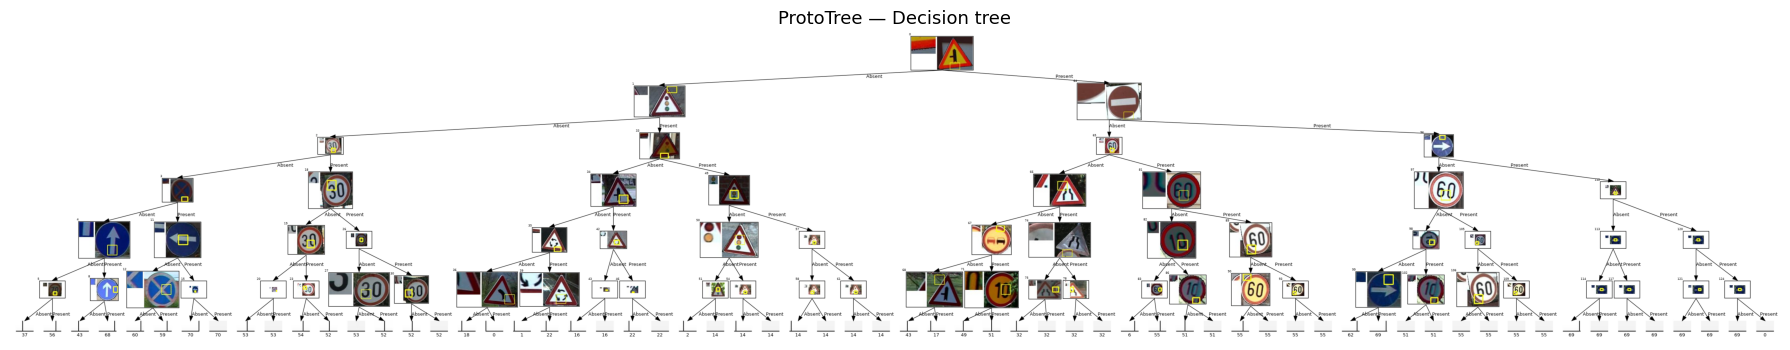

In [ ]:
# ── Display decision tree PDF converted to PNG via graphviz ──────────────────
DOT_PATH      = "../checkpoints/prototree/pruned_and_projected/treevis.dot"
TREE_PNG_PATH = str(RESULTS_DIR / "treevis.png")

os.system(f"dot -Tpng -Gmargin=0 {DOT_PATH} -o {TREE_PNG_PATH}")

if os.path.exists(TREE_PNG_PATH):
    tree_img = Image.open(TREE_PNG_PATH)
    fig, ax  = plt.subplots(figsize=(18, 12))
    ax.imshow(tree_img)
    ax.axis("off")
    ax.set_title("ProtoTree — Decision tree", fontsize=13)
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / "treevis_display.png", dpi=150)
    plt.show()
else:
    print(f" PNG not generated. Check that graphviz (dot) is installed.")

In [ ]:
# ── Local Explanation - 2 images per selected class (using the 'main_explain_local.py' ProtoTree's script) ──────────────────

CROPS_TEST_DIR      = str(CROPS_SPLIT_DIR / "test")
PROTOTREE_CKPT_PATH = "../checkpoints/prototree/checkpoints/pruned_and_projected"
LOG_DIR             = "../checkpoints/prototree"
TREE_PDF_PATH       = "../checkpoints/prototree/pruned_and_projected/treevis.pdf"

IMAGES_PER_CLASS = 2

# Collect all class folders in the test split
all_classes = sorted([
    d for d in os.listdir(CROPS_TEST_DIR)
    if os.path.isdir(os.path.join(CROPS_TEST_DIR, d))
])
print(f"Classes found in test set: {all_classes}")
print(f"Running local explanation for {IMAGES_PER_CLASS} images per class ({len(all_classes)} classes total)...\n")

# ── Loop: 2 random images per class ──────────────────────────────────────────
for cls in all_classes:
    cls_dir = os.path.join(CROPS_TEST_DIR, cls)
    imgs    = glob.glob(os.path.join(cls_dir, "*.jpg")) + glob.glob(os.path.join(cls_dir, "*.png"))
    if not imgs:
        print(f"  [Class {cls}] No images found, skipping.")
        continue

    selected = random.sample(imgs, min(IMAGES_PER_CLASS, len(imgs)))

    for img_path in selected:
        print(f"  Explain → class {cls} | {os.path.basename(img_path)}")
        result = subprocess.run(
            [
                "python3", "ProtoTree/main_explain_local.py",
                "--prototree", PROTOTREE_CKPT_PATH,
                "--log_dir",   LOG_DIR,
                "--dataset",   "traffic_signs",
                "--sample_dir", img_path,
            ],
            capture_output=True, text=True
        )
        if result.returncode != 0:
            print(f"    ERROR: {result.stderr[-300:]}")

print(f"\nExplanations completed.")


Classes found in test set: ['0', '1', '14', '16', '17', '18', '2', '22', '32', '37', '43', '49', '51', '52', '53', '54', '55', '56', '59', '6', '60', '62', '68', '69', '70']
Running local explanation for 2 images per class (25 classes total)...

  Explain → class 0 | 0013509_crop_1.jpg
  Explain → class 0 | 0009252_crop_1.jpg
  Explain → class 1 | 0013917_crop_2.jpg
  Explain → class 1 | 0012267_crop_3.jpg
  Explain → class 14 | 0004510_crop_3.jpg
  Explain → class 14 | 0007691_crop_2.jpg
  Explain → class 16 | 0007398_crop_0.jpg
  Explain → class 16 | 0016125_crop_0.jpg
  Explain → class 17 | 0008282_crop_2.jpg
  Explain → class 17 | 0001013_crop_0.jpg
  Explain → class 18 | 0014093_crop_1.jpg
  Explain → class 18 | 0016167_crop_4.jpg
  Explain → class 2 | 0014425_crop_1.jpg
  Explain → class 2 | 0007485_crop_0.jpg
  Explain → class 22 | 0013797_crop_2.jpg
  Explain → class 22 | 0011054_crop_3.jpg
  Explain → class 32 | 0008795_crop_3.jpg
  Explain → class 32 | 0005528_crop_3.jpg
  Ex

Found 51 explanation folders.


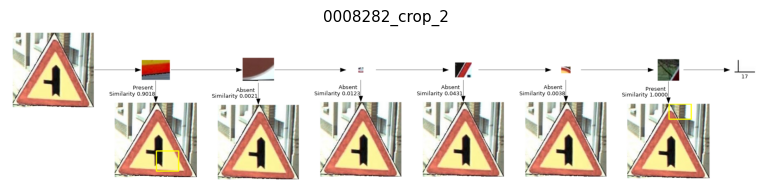

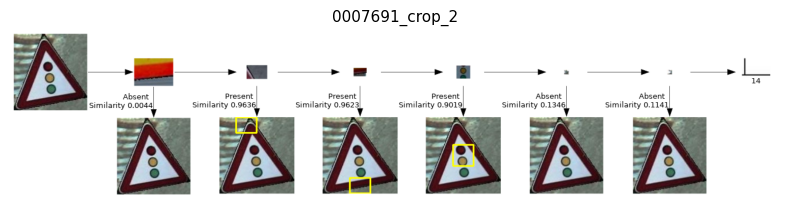

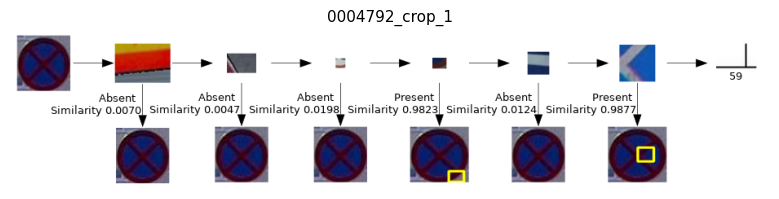

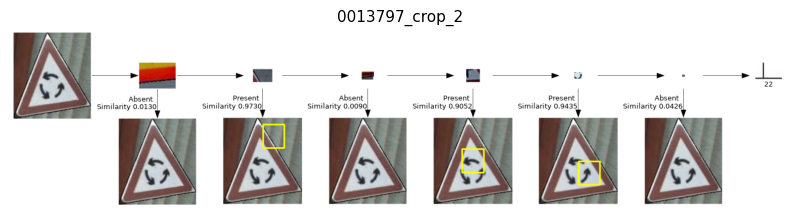

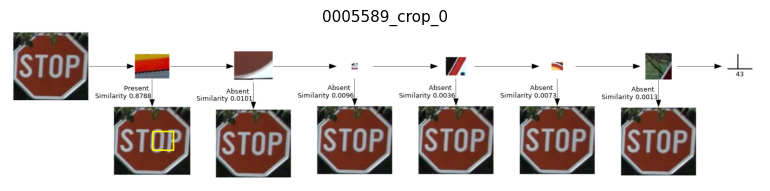

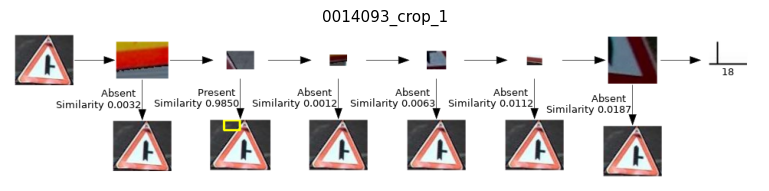

In [ ]:
# ── Display predvis for 6 random explanation samples ─────
LOCAL_EXPL_DIR = "../checkpoints/prototree/local_explanations"

# Collect all subfolders that contain a predvis.dot
all_explanation_folders = sorted([
    os.path.join(LOCAL_EXPL_DIR, d)
    for d in os.listdir(LOCAL_EXPL_DIR)
    if os.path.isdir(os.path.join(LOCAL_EXPL_DIR, d))
    and os.path.exists(os.path.join(LOCAL_EXPL_DIR, d, "predvis.dot"))
])

selected_folders = random.sample(all_explanation_folders, min(6, len(all_explanation_folders)))

# Display the explanations
for folder in selected_folders:
    dot_path = os.path.join(folder, "predvis.dot")
    png_path = os.path.join(folder, "predvis.png")

    ret = os.system(f"dot -Tpng -Gmargin=0 {dot_path} -o {png_path}")

    if ret == 0 and os.path.exists(png_path):
        img = Image.open(png_path)
        w, h  = img.size
        fig_h = 10 * h / w
        fig, ax = plt.subplots(figsize=(18, fig_h))
        ax.imshow(img)
        ax.set_title(os.path.basename(folder), fontsize=11)
        ax.axis("off")
        plt.tight_layout()
        plt.savefig(RESULTS_DIR / f"predvis_{os.path.basename(folder)}.png", dpi=150)
        plt.show()
    else:
        print(f"  ERROR converting {os.path.basename(folder)}")

---
## 12. ProtoTree Evaluation <a id='12-prototree-eval'></a>

In [52]:
# ── Test accuracy ─────────────────────────────────────────────────────────────
PROTOTREE_LOG_DIR = CHECKPOINTS_DIR / "prototree"
epoch_log = pd.read_csv(PROTOTREE_LOG_DIR / "log_epoch_overview.csv")

# Print the last 5 epochs
print(epoch_log.tail())
best_row = epoch_log.loc[epoch_log["test_acc"].idxmax()]
best_test_acc = best_row["test_acc"]
best_epoch = int(best_row["epoch"])
print(f"\nBest test accuracy achieved during training: {best_test_acc:.4f} at epoch {best_epoch}")

    epoch  test_acc  mean_train_acc  mean_train_crossentropy_loss_during_epoch
95     96  0.971330        0.987825                                   0.196370
96     97  0.971330        0.986288                                   0.198451
97     98  0.971330        0.987825                                   0.203522
98     99  0.971330        0.986491                                   0.201245
99    100  0.973624        0.988115                                   0.198620

Best test accuracy achieved during training: 0.9748 at epoch 94


Inference: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 14/14 [00:01<00:00, 12.71it/s]


              precision    recall  f1-score   support

           0       0.91      0.97      0.94        33
           1       0.93      0.90      0.92        31
           2       1.00      1.00      1.00        31
           3       1.00      0.97      0.98        31
           4       1.00      1.00      1.00        32
           5       0.97      1.00      0.98        31
           6       1.00      0.97      0.99        36
           7       1.00      1.00      1.00        30
           8       1.00      1.00      1.00        31
           9       0.96      1.00      0.98        75
          10       0.96      0.98      0.97        52
          11       1.00      0.93      0.97        30
          12       1.00      1.00      1.00        30
          13       1.00      0.91      0.95        33
          14       0.97      0.97      0.97        37
          15       0.94      1.00      0.97        31
          16       1.00      0.94      0.97        33
          17       1.00    

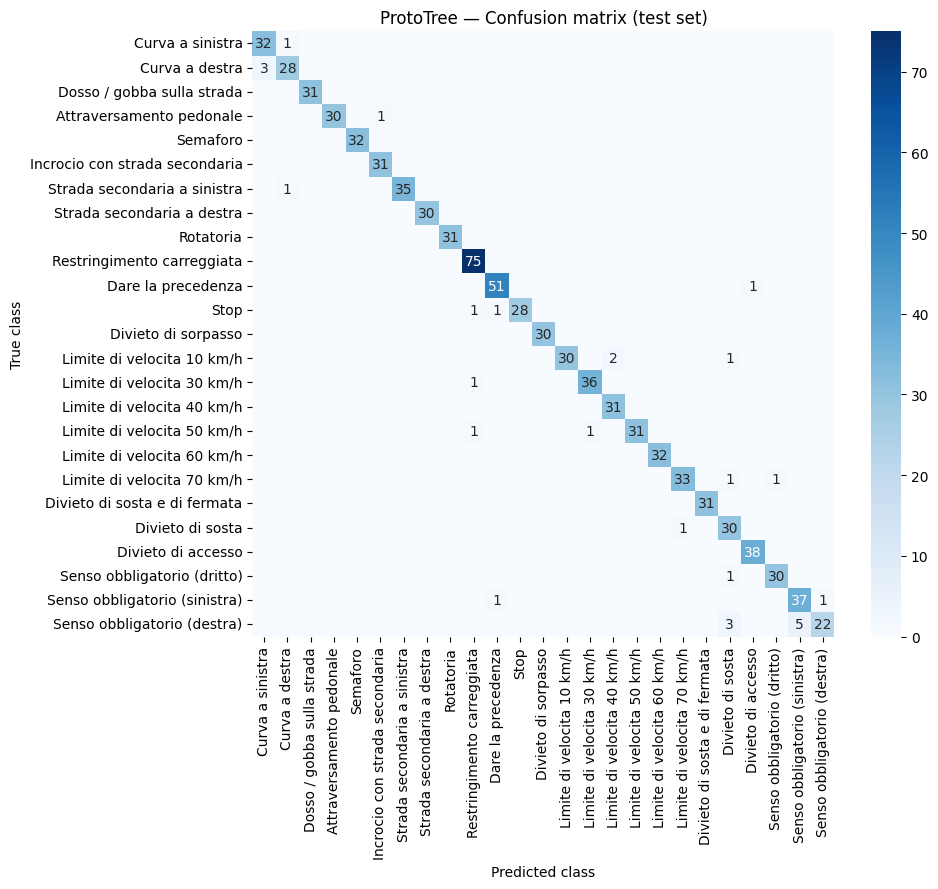

In [ ]:
# ── Per-class report & confusion matrix ───────────────────────────────────────

PROTOTREE_CKPT = CHECKPOINTS_DIR / "prototree" / "checkpoints" / "pruned_and_projected"

# Load the saved ProtoTree model and move it to the execution device (CPU/GPU)
tree = ProtoTree.load(str(PROTOTREE_CKPT)).to(DEVICE)
# Set the model to evaluation (inference) mode (disables dropout, batch normalization, etc.)
tree.eval()

# Standard ImageNet mean and standard deviation for normalization
MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]

# Preprocessing pipeline for evaluation images
eval_transform = transforms.Compose([
    transforms.Resize((224, 224)),            # Resize images to 224x224 (expected by ResNet50)
    transforms.ToTensor(),                    # Convert image to PyTorch tensor
    transforms.Normalize(mean=MEAN, std=STD), # Normalize pixel values based on ImageNet stats
])

# Load evaluation crops using PyTorch's ImageFolder
test_dataset = ImageFolder(str(CROPS_SPLIT_DIR / "test"), transform=eval_transform)
# Create a DataLoader for batch processing during evaluation
test_loader  = DataLoader(
    test_dataset,
    batch_size=64,                      # Process 64 images per batch
    shuffle=False,                      # Do not shuffle to maintain alignment for evaluations
    num_workers=4,                      # Load data in parallel using 4 worker processes
    pin_memory=(DEVICE.type=="cuda")    # Speed up transfer from CPU host to GPU memory if CUDA is used
)

# Extract the class names using the SELECTED_CLASSES indices (as done for YOLO)
class_names_pt = [CLASS_NAMES[c] for c in SELECTED_CLASSES]

# Run inference on the test set to collect predictions and ground truth labels
all_preds, all_labels = [], []
with torch.no_grad():
    for imgs, labels in tqdm(test_loader, desc="Inference"):
        # Get model outputs (logits) for the batch
        logits, _ = tree.forward(imgs.to(DEVICE))
        # Select the class with the highest probability (argmax) and store it
        all_preds.extend(logits.argmax(dim=1).cpu().numpy())
        # Store the actual ground truth labels
        all_labels.extend(labels.numpy())

print(classification_report(all_labels, all_preds, zero_division=0))

# Generate confusion matrix
cm = confusion_matrix(all_labels, all_preds)

annot_labels = np.where(cm > 0, cm.astype(int).astype(str), "")
fig, ax = plt.subplots(figsize=(10, 9))

sns.heatmap(cm, annot=annot_labels, fmt="", cmap="Blues", 
            xticklabels=class_names_pt, yticklabels=class_names_pt, ax=ax)

ax.set_xlabel("Predicted class")
ax.set_ylabel("True class")
ax.set_title("ProtoTree — Confusion matrix (test set)")

plt.xticks(rotation=90)
plt.yticks(rotation=0)

plt.tight_layout()
plt.savefig(RESULTS_DIR / "prototree_confusion_matrix.png", dpi=150)
plt.show()

---
## 13. End-to-End Pipeline <a id='13-pipeline'></a>

Given a raw street image:
1. YOLO detects signs (bounding boxes)
2. Each crop is passed to ProtoTree for interpretable classification
3. Output is annotated with macro-class colour, class name and confidence

Processing specific image: 0000130.jpg
Saved YOLO output to: ../results/YOLO_0000130.png


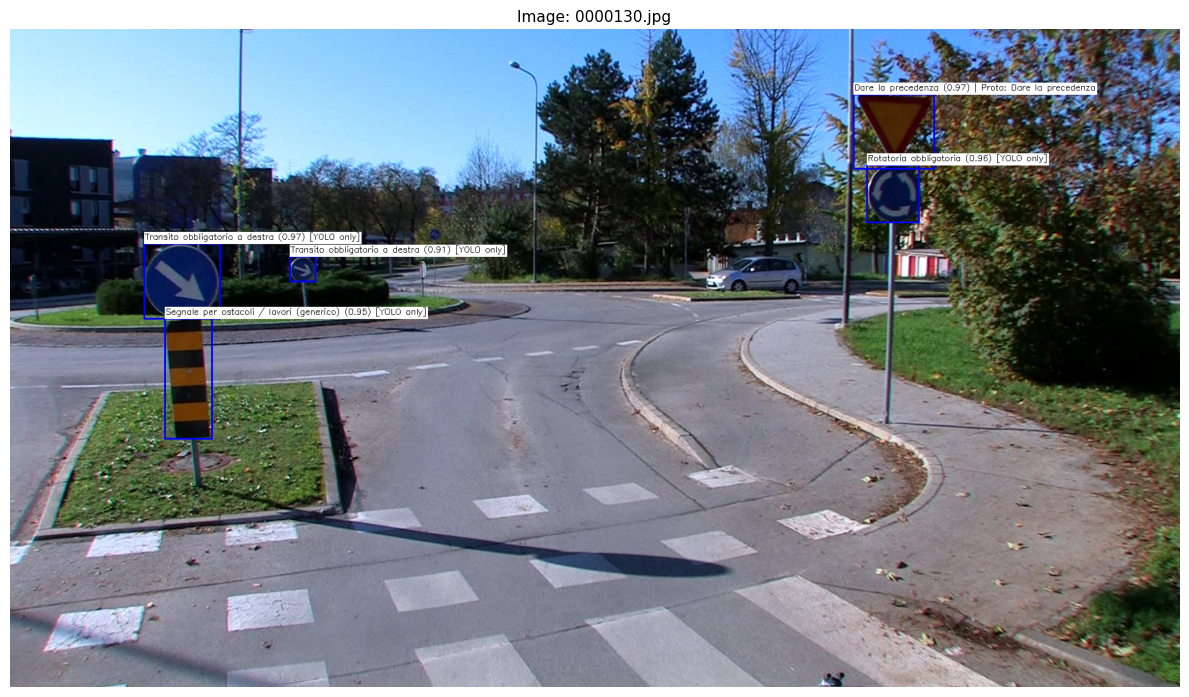

   Running local explanation for box 0 (Proto class: Dare la precedenza)...
     Saved Tree explanation to: ../results/TREE_0000130_box_0.png


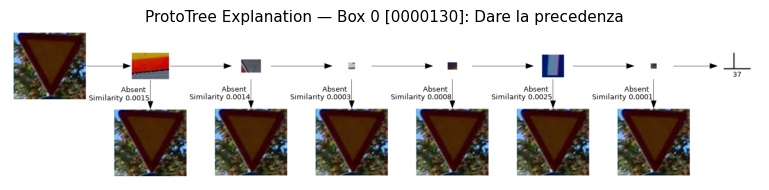

In [32]:
# Define useful paths
PROTOTREE_CKPT_PATH = "../checkpoints/prototree/checkpoints/pruned_and_projected"
LOG_DIR = "../checkpoints/prototree"
LOCAL_EXPL_DIR = Path("../checkpoints/prototree/local_explanations")

# Load class mapping: ProtoTree index -> original YOLO class id
mapping_path = CROPS_SPLIT_DIR / "class_mapping.json"
with open(mapping_path, "r") as f:
    mapping = json.load(f)

# Load the saved ProtoTree model if not already done
tree = ProtoTree.load(str(PROTOTREE_CKPT_PATH)).to(DEVICE)
tree.eval()

# Redefine eval_transform if not already defined
MEAN = [0.485, 0.456, 0.406]
STD = [0.229, 0.224, 0.225]
eval_transform = transforms.Compose(
    [
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=MEAN, std=STD),
    ]
)

# Select a specific image by name
target_image_name = "0000130.jpg"

matching_paths = list(IMAGES_DIR.glob(f"**/{target_image_name}"))
if len(matching_paths) == 0:
    raise FileNotFoundError(
        f"Image '{target_image_name}' not found inside {IMAGES_DIR}"
    )

sample_imgs = pd.DataFrame({"image": [matching_paths[0]]})
print(f"Processing specific image: {matching_paths[0].name}")

# Reset the video tracker (used in Section 14)
best_model.predictor = None
best_model.callbacks['on_predict_postprocess_end'] = []

# Main loop over the dataframe
for row_idx, (_, row) in enumerate(sample_imgs.iterrows()):
    img_path = row["image"]
    img_bgr = cv2.imread(str(img_path))
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    h, w = img_rgb.shape[:2]
    base_name = Path(img_path).stem

    # Yolo prediction
    results = best_model.predict(
        str(img_path), conf=0.25, verbose=False
    )[0]
    annotated = img_rgb.copy()

    crops_for_explanation = []

    for box_idx, box in enumerate(results.boxes):
        yolo_cid = int(box.cls.item())
        conf = float(box.conf.item())  # YOLO detection confidence
        x1, y1, x2, y2 = map(int, box.xyxy[0].tolist())
        sign_name = CLASS_NAMES.get(yolo_cid, f"class {yolo_cid}")

        if yolo_cid not in SELECTED_CLASSES:
            label = f"{sign_name} ({conf:.2f}) [YOLO only]"
            proto_cid = None
        else:
            # Crop extraction
            crop = Image.fromarray(img_rgb[y1:y2, x1:x2])
            tensor = eval_transform(crop).unsqueeze(0).to(DEVICE)

            # ProtoTree prediction
            with torch.no_grad():
                logits, _ = tree.forward(tensor)
                proto_idx = int(logits.argmax(dim=1).item())

            proto_cid = int(mapping[str(proto_idx)])
            label = f"{sign_name} ({conf:.2f}) | Proto: {CLASS_NAMES.get(proto_cid, proto_cid)}"

            tmp_crop_path = RESULTS_DIR / f"tmp_crop_{row_idx}_{box_idx}.jpg"
            crop.save(str(tmp_crop_path))
            crops_for_explanation.append((box_idx, tmp_crop_path, proto_cid))

        # ── Draw bounding boxes ──────────────────────────────────────────────
        cv2.rectangle(annotated, (x1, y1), (x2, y2), (0, 0, 255), 2)

        # ── Render prediction text labels ─────────────────────────────────────
        font = cv2.FONT_HERSHEY_SIMPLEX
        font_scale = 0.45
        thickness = 1
        (tw, th), baseline = cv2.getTextSize(label, font, font_scale, thickness)
        cv2.rectangle(
            annotated,
            (x1, max(y1 - th - baseline - 4, 0)),
            (x1 + tw + 2, max(y1, th + baseline + 4)),
            (255, 255, 255),
            -1,
        )
        cv2.putText(
            annotated,
            label,
            (x1 + 1, max(y1 - baseline - 2, th)),
            font,
            font_scale,
            (0, 0, 0),
            thickness,
        )

    # ── Display and save the YOLO detection output ────────────────────────────
    fig, ax = plt.subplots(1, 1, figsize=(12, 7))
    ax.imshow(annotated)
    ax.axis("off")
    ax.set_title(f"Image: {base_name}.jpg", fontsize=11)
    plt.tight_layout()

    yolo_save_path = RESULTS_DIR / f"YOLO_{base_name}.png"
    plt.savefig(yolo_save_path, dpi=150, bbox_inches="tight")
    print(f"Saved YOLO output to: {yolo_save_path}")
    plt.show()

    # ── ProtoTree local explanation generation ────────────────────────────────
    for box_idx, tmp_crop_path, proto_cid in crops_for_explanation:
        print(
            f"   Running local explanation for box {box_idx} "
            f"(Proto class: {CLASS_NAMES.get(proto_cid, proto_cid)})..."
        )

        result = subprocess.run(
            [
                "python3",
                "ProtoTree/main_explain_local.py",
                "--prototree",
                PROTOTREE_CKPT_PATH,
                "--log_dir",
                LOG_DIR,
                "--dataset",
                "traffic_signs",
                "--sample_dir",
                str(tmp_crop_path),
            ],
            capture_output=True,
            text=True,
        )

        if result.returncode != 0:
            print(f"     ERROR: {result.stderr[-300:]}")
            tmp_crop_path.unlink(missing_ok=True)
            continue

        crop_stem = tmp_crop_path.stem
        specific_dot_path = LOCAL_EXPL_DIR / crop_stem / "predvis.dot"
        png_path = LOCAL_EXPL_DIR / crop_stem / "predvis.png"

        if specific_dot_path.exists():
            os.system(f"dot -Tpng -Gmargin=0 {specific_dot_path} -o {png_path}")

            if png_path.exists():
                expl_img = Image.open(png_path)
                iw, ih = expl_img.size
                fig_h = 10 * ih / iw
                fig, ax = plt.subplots(figsize=(18, fig_h))
                ax.imshow(expl_img)
                ax.set_title(
                    f"ProtoTree Explanation — Box {box_idx} [{base_name}]: "
                    f"{CLASS_NAMES.get(proto_cid, proto_cid)}",
                    fontsize=11,
                )
                ax.axis("off")
                plt.tight_layout()

                # Save ProtoTree tree visualization in RESULTS_DIR
                tree_save_path = (
                    RESULTS_DIR / f"TREE_{base_name}_box_{box_idx}.png"
                )
                plt.savefig(tree_save_path, dpi=150, bbox_inches="tight")
                print(f"     Saved Tree explanation to: {tree_save_path}")
                plt.show()
            else:
                print(
                    f"     ERROR: Could not convert dot to PNG for {crop_stem}"
                )
        else:
            print(
                f"     ERROR: Explanation file missing at {specific_dot_path}"
            )

        # Delete the temporany crop
        tmp_crop_path.unlink(missing_ok=True)

# Agreement YOLO vs ProtoTree across the whole test set
This subsection evaluates the **agreement rate** between the predictions of YOLO and ProtoTree across the entire test set.

ProtoTree does not replace YOLO; rather, it acts as an interpretable surrogate. By measuring how much ProtoTree's classifications agree with YOLO's predictions on the cropped signs, we validate the reliability and fidelity of our model explanations.

In [33]:
# Filter the main dataframe to keep only the test split images
test_df = df[df["image"].apply(lambda p: p.stem).isin(test_list)]

agreement_count = 0
total_count     = 0
per_class_agreement = {cid: {"agree": 0, "total": 0} for cid in SELECTED_CLASSES}

for _, row in tqdm(test_df.iterrows(), total=len(test_df), desc="Agreement eval"):
    img_path = row["image"]
    img_bgr  = cv2.imread(str(img_path))
    if img_bgr is None:
        continue
    img_rgb  = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    results = best_model.predict(str(img_path), conf=0.25, verbose=False)[0]

    for box in results.boxes:
        yolo_cid = int(box.cls.item())
        if yolo_cid not in SELECTED_CLASSES:
            continue   # we evaluate agreement only on classes that ProtoTree knows

        x1, y1, x2, y2 = map(int, box.xyxy[0].tolist())
        crop = Image.fromarray(img_rgb[y1:y2, x1:x2])
        tensor = eval_transform(crop).unsqueeze(0).to(DEVICE)
        
        with torch.no_grad():
            logits, _ = tree.forward(tensor)
            proto_idx = int(logits.argmax(dim=1).item())
        
        proto_cid = int(mapping[str(proto_idx)])

        total_count += 1
        per_class_agreement[yolo_cid]["total"] += 1
        if proto_cid == yolo_cid:
            agreement_count += 1
            per_class_agreement[yolo_cid]["agree"] += 1

# Overall agreement
agreement_rate = agreement_count / total_count if total_count else 0
print(f"Overall YOLO/ProtoTree agreement: {agreement_rate:.4f} ({agreement_count}/{total_count})")

# Compute per-class agreement
agree_df = pd.DataFrame([
    {"class": cid, "agreement": v["agree"]/v["total"] if v["total"] else None, "n": v["total"]}
    for cid, v in per_class_agreement.items()
]).sort_values("agreement")
print(agree_df)

Agreement eval: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2085/2085 [03:53<00:00,  8.94it/s]

Overall YOLO/ProtoTree agreement: 0.9303 (788/847)
    class  agreement   n
24     70   0.628571  35
23     69   0.777778  36
1       1   0.810811  37
6      17   0.864865  37
5      16   0.903226  31
15     53   0.909091  33
0       0   0.911765  34
7      18   0.925926  27
14     52   0.935484  31
3       6   0.937500  32
18     56   0.941176  34
21     62   0.945946  37
13     51   0.965517  29
16     54   0.966667  30
17     55   0.966667  30
19     59   0.966667  30
4      14   0.967742  31
8      22   0.967742  31
11     43   0.979592  49
2       2   1.000000  32
12     49   1.000000  27
10     37   1.000000  64
9      32   1.000000  30
20     60   1.000000  29
22     68   1.000000  31


---
## 14. Video Demo with YOLO <a id='14-video-demo'></a>

Runs the best YOLO model on a full street video, tracking detected signs across frames (with class smoothing via majority voting on each track ID) and exporting the annotated result.

In [ ]:
# Video processing with yolo
def process_video_yolo(video_path, output_path, yolo_model, conf_thresh=0.40,
                            imgsz=640, smooth_window=5):
    # Open the source video
    cap = cv2.VideoCapture(str(video_path))
    if not cap.isOpened():
        print(f"Error: Unable to open the source video at {video_path}")
        return

    # Extract video metadata
    width        = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height       = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    fps          = cap.get(cv2.CAP_PROP_FPS)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    out = cv2.VideoWriter(str(output_path), fourcc, fps, (width, height))
    print(f" Starting video processing ({total_frames} total frames)...")

    # Buffer for class smoothing per track ID
    track_history = defaultdict(list)

    frame_idx = 0
    while cap.isOpened():
        ret, frame_bgr = cap.read()
        if not ret:
            break

        # persist=True keeps tracking IDs consistent across frames
        results = yolo_model.track(frame_bgr, persist=True, conf=conf_thresh,
                                   imgsz=imgsz, verbose=False)[0]
        annotated = frame_bgr.copy()

        if results.boxes is not None and len(results.boxes) > 0:
            for box in results.boxes:
                x1, y1, x2, y2 = map(int, box.xyxy[0].tolist())
                yolo_class = int(box.cls[0].item())
                yolo_conf  = float(box.conf[0].item())

                # ── Class smoothing via majority voting on the track ID ──
                track_id = int(box.id[0].item()) if box.id is not None else None
                if track_id is not None:
                    track_history[track_id].append(yolo_class)
                    track_history[track_id] = track_history[track_id][-smooth_window:]
                    yolo_class_smoothed = Counter(track_history[track_id]).most_common(1)[0][0]
                else:
                    yolo_class_smoothed = yolo_class    

                yolo_sign_name = CLASS_NAMES.get(yolo_class_smoothed, f"class {yolo_class_smoothed}")
                macro  = CLASS_TO_MACRO.get(yolo_class_smoothed, "other")
                color  = MACRO_COLORS.get(macro, (0, 255, 0))

                cv2.rectangle(annotated, (x1, y1), (x2, y2), color, 2)

                label = f"{yolo_sign_name} ({yolo_conf:.2f})"
                font, scale, thick = cv2.FONT_HERSHEY_SIMPLEX, 0.45, 1
                (tw, th), baseline = cv2.getTextSize(label, font, scale, thick)
                box_w, box_h = tw + 6, th + baseline + 6
                y_bg_start = max(0, y1 - box_h)

                cv2.rectangle(annotated, (x1, y_bg_start), (x1 + box_w, y1), color, -1)
                cv2.putText(annotated, label, (x1 + 3, y1 - baseline), font, scale, (255, 255, 255), thick)

        out.write(annotated)
        frame_idx += 1
        if frame_idx % 30 == 0 or frame_idx == total_frames:
            print(f" Progress: {frame_idx}/{total_frames} frames processed.")

    cap.release()
    out.release()
    print(f" Video successfully saved at: {output_path}")


# Execution
VIDEO_INPUT  = "../dash-cam.mov"
VIDEO_OUTPUT = "../output_dash-cam.mov"

process_video_yolo(VIDEO_INPUT, VIDEO_OUTPUT, best_model,
                    conf_thresh=0.40, imgsz=960, smooth_window=5)